
<div style="text-align: center; padding: 30px 10px;">

<h1 style="color:#ff7500; font-size: 24px; margin-bottom: 10px;">
МФТИ ФПМИ
</h1>

<h2 style="font-size: 30px; margin-top: 5px;">
Практикум Python - Phys&Math Поток
</h2>

<hr style="width: 60%; border: 1px solid #10069f; margin: 25px auto;">

<h3 style="font-size: 36px;">
6. Pandas. CSV.
</h3>

<p style="margin-top: 20px;">
<strong>Дата:</strong> 10-12 марта 2026 года<br>
</p>

<p style="margin-top: 25px;">
Данный ноутбук является частью серии семинаров по курсу  
<em>«Практикум Python»</em> и предназначен для учебных и образовательных целей.
</p>

</div>


## План занятия

- Обсудим формат CSV
- Обсудим, кто такой DataFrame
- Сравним DataFrame и Series
- Обсудим продвинутые методы работы с DataFrame

In [17]:
pip install pandas

   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.7 MB 5.5 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/9.7 MB 6.2 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.7 MB 7.7 MB/s eta 0:00:01
   ---------------------- ----------------- 5.5/9.7 MB 8.1 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.7 MB 7.9 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.7 MB 7.9 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 7.8 MB/s  0:00:01
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.6/12.3 MB 8.7 MB/s eta 0:00:02
   ----------- ---------------------------- 3.4/12.3 MB 8.6 MB/s eta 0:00:02
   ----------------- ---------------------- 5.2/12.3 MB 8.6 MB/s eta 0:00:01
   ---------------------- ----------------- 6.8/12.3 MB 8.7 MB/s eta 0:00:01
   ---------------------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [85]:
import csv
import numpy as np
import pandas as pd
import time

## Что такое CSV?

Довольно часто нам приходится работать с данными в формате таблицы:

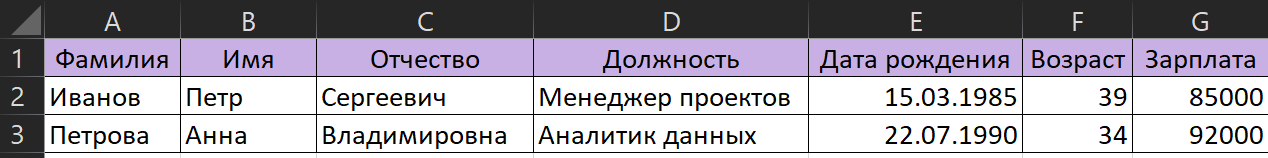

<strong style="color:#ff7500; margin-bottom: 10px;">
Вопрос: как можно хранить табличные данные самым простым способом?
</strong>

.

.

.

.

.

.



Можем хранить в текстовом файле, разделять ячейки через запятую, а строки - через \n.

In [6]:
%%writefile employees.csv
Фамилия,Имя,Отчество,Должность,Дата_рождения,Возраст,Зарплата
Иванов,Петр,Сергеевич,Менеджер проектов,1985-03-15,39,85000
Петрова,Анна,Владимировна,Аналитик данных,1990-07-22,34,92000
Сидоров,Дмитрий,Игоревич,Разработчик Python,1988-11-30,36,110000
Козлова,Елена,Александровна,Дизайнер UX/UI,1992-05-18,32,78000
Новиков,Алексей,Павлович,DevOps инженер,1983-09-10,41,125000
Морозова,Ольга,Дмитриевна,Маркетолог,1995-01-25,29,67000
Волков,Сергей,Андреевич,Тестировщик,1991-12-08,33,72000
Лебедева,Мария,Ивановна,Руководитель отдела,1980-06-14,44,150000
Соколов,Андрей,Викторович,Бэкенд-разработчик,1987-04-03,37,105000
Федорова,Татьяна,Сергеевна,Фронтенд-разработчик,1993-08-19,31,95000
Кузнецов,Максим,Олегович,Системный администратор,1986-02-28,38,88000
Антонова,Ирина,Петровна,HR-специалист,1994-10-11,30,65000
Павлов,Артем,Константинович,Продукт-менеджер,1989-07-07,35,98000
Семенова,Юлия,Алексеевна,Бухгалтер,1984-12-23,40,82000
Григорьев,Иван,Николаевич,Android-разработчик,1996-03-30,28,102000

Overwriting employees.csv


PermissionError: [Errno 13] Permission denied: 'employees.csv'

В теории мы можем работать через модуль `csv`. Его синтаксис очень похож на синтаксис обычного открытия файлов в Python.

In [ ]:
with open('employees.csv', encoding='utf-8') as csvfile:
    spamreader = csv.reader(csvfile)
    for row in spamreader:
        print(' - '.join(row), ";")

print(6)

Фамилия - Имя - Отчество - Должность - Дата_рождения - Возраст - Зарплата ;
Иванов - Петр - Сергеевич - Менеджер проектов - 1985-03-15 - 39 - 85000 ;
Петрова - Анна - Владимировна - Аналитик данных - 1990-07-22 - 34 - 92000 ;
Сидоров - Дмитрий - Игоревич - Разработчик Python - 1988-11-30 - 36 - 110000 ;
Козлова - Елена - Александровна - Дизайнер UX/UI - 1992-05-18 - 32 - 78000 ;
Новиков - Алексей - Павлович - DevOps инженер - 1983-09-10 - 41 - 125000 ;
Морозова - Ольга - Дмитриевна - Маркетолог - 1995-01-25 - 29 - 67000 ;
Волков - Сергей - Андреевич - Тестировщик - 1991-12-08 - 33 - 72000 ;
Лебедева - Мария - Ивановна - Руководитель отдела - 1980-06-14 - 44 - 150000 ;
Соколов - Андрей - Викторович - Бэкенд-разработчик - 1987-04-03 - 37 - 105000 ;
Федорова - Татьяна - Сергеевна - Фронтенд-разработчик - 1993-08-19 - 31 - 95000 ;
Кузнецов - Максим - Олегович - Системный администратор - 1986-02-28 - 38 - 88000 ;
Антонова - Ирина - Петровна - HR-специалист - 1994-10-11 - 30 - 65000 ;
Павлов

<strong style="color:#ff7500; margin-bottom: 10px;">
Вопрос: какие есть плюсы и минусы у такого подхода?
</strong>

.

.

.

.

.

.



Плюсы: синтаксис Python совпадает с обычным открытием файлов
Минусы: 1) не хватает ООП подхода, в основном предполагается только обход циклами
2) Хочется ускориться по времени

In [15]:
start_time = time.time()

for _ in range(1000):
    sm = 0
    am = 0
    with open('employees.csv', encoding='utf-8') as csvfile:
        spamreader = csv.reader(csvfile)
        for row in spamreader:
            if row[6] != "Зарплата":
                sm += int(row[6])
                am += 1
        ans = sm / am


end_time = time.time() 
elapsed_time = end_time - start_time
print(f"Время выполнения: {elapsed_time:.6f} секунд")

Время выполнения: 0.099952 секунд


In [19]:
start_time = time.time()

for _ in range(1000):
    sm = 0
    am = 0
    df = pd.read_csv('employees.csv')
    ans = df["Зарплата"].mean()


end_time = time.time() 
elapsed_time = end_time - start_time
print(f"Время выполнения: {elapsed_time:.6f} секунд")

Время выполнения: 0.711300 секунд


<strong style="color:#ff7500; margin-bottom: 10px;">
Вопрос: что не так?
</strong>

.

.

.

.

.

.





In [21]:
start_time = time.time()

df = pd.read_csv('employees.csv')
for _ in range(1000):
    ans = df["Зарплата"].mean()


end_time = time.time() 
elapsed_time = end_time - start_time
print(f"Время выполнения: {elapsed_time:.6f} секунд")

Время выполнения: 0.024474 секунд


## DataFrame - основы

### Способы создания датафрейма

DataFrame можно создать из различных источников данных: списков, словарей, массивов NumPy или Series.

**Синтаксис**:
```python
pd.DataFrame(data, index=None, columns=None, dtype=None)
```

- **data** — основные данные, из которых будет создан DataFrame. Это может быть список, словарь, массив NumPy или Series.
- **index** — индексы строк DataFrame. Если не указаны, будут использоваться стандартные числовые индексы.
- **columns** — имена столбцов. Это список строк, которые указывают, как будут называться столбцы в результирующем DataFrame.
- **dtype** — тип данных, который будет использоваться для всех данных в DataFrame.

In [27]:
# словарь
urban_population = {
    'MSK': 12655050,
    'NN': 1226586,
    'SPB': 5384342,
    'KLN': 1589785
}

urban_series = pd.Series(urban_population)
urban_frame = pd.DataFrame(urban_series, columns=['population'])

urban_frame

,population
MSK,12655050
NN,1226586
SPB,5384342
KLN,1589785


In [29]:
# а если несколько столбцов?

data = [{'a': i, 'b': i ** 2} for i in range(10)]
square_data = pd.DataFrame(data)
square_data

,a,b
0,0,0
1,1,1
2,2,4
3,3,9
4,4,16
5,5,25
6,6,36
7,7,49
8,8,64
9,9,81


In [30]:
# из списков
pd.DataFrame(data=[['BTC', 10000],['LTC', 200],['XRP', 1]],
             columns=['symbol', 'price'])

,symbol,price
0,BTC,10000
1,LTC,200
2,XRP,1


Но самый частый - конечно, pd.read_csv

In [100]:
pd.read_csv?

Signature:
pd.read_csv(
    filepath_or_buffer: 'FilePath | ReadCsvBuffer[bytes] | ReadCsvBuffer[str]',
    *,
    sep: 'str | None | lib.NoDefault' = <no_default>,
    delimiter: 'str | None | lib.NoDefault' = None,
    header: "int | Sequence[int] | None | Literal['infer']" = 'infer',
    names: 'Sequence[Hashable] | None | lib.NoDefault' = <no_default>,
    index_col: 'IndexLabel | Literal[False] | None' = None,
    usecols: 'UsecolsArgType' = None,
    dtype: 'DtypeArg | None' = None,
    engine: 'CSVEngine | None' = None,
    converters: 'Mapping[HashableT, Callable] | None' = None,
    true_values: 'list | None' = None,
    false_values: 'list | None' = None,
    skipinitialspace: 'bool' = False,
    skiprows: 'list[int] | int | Callable[[Hashable], bool] | None' = None,
    skipfooter: 'int' = 0,
    nrows: 'int | None' = None,
    na_values: 'Hashable | Iterable[Hashable] | Mapping[Hashable, Iterable[Hashable]] | None' = None,
    keep_default_na: 'bool' = True,
    na_filter: 

### Базовые функции

In [ ]:
# Как в numpy (Без dtype тк у каждого столбца мб разные) размеры, является ли пустым, размерность, количество элементов
urban_frame.shape, urban_frame.empty, urban_frame.ndim, urban_frame.size

# Заметим, что это атрибуты, а не методы! Скобки не нужны

((4, 1), False, 2, 4)

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Фамилия        15 non-null     str  
 1   Имя            15 non-null     str  
 2   Отчество       15 non-null     str  
 3   Должность      15 non-null     str  
 4   Дата_рождения  15 non-null     str  
 5   Возраст        15 non-null     int64
 6   Зарплата       15 non-null     int64
dtypes: int64(2), str(5)
memory usage: 972.0 bytes


In [35]:
df.describe()

,Возраст,Зарплата
count,15.000000,15.000000
mean,35.133333,94266.666667
std,4.718757,22565.671357
min,28.000000,65000.000000
25%,31.500000,80000.000000
50%,35.000000,92000.000000
75%,38.500000,103500.000000
max,44.000000,150000.000000


### Визуализация датафреймов

In [36]:
df

,Фамилия,Имя,Отчество,Должность,Дата_рождения,Возраст,Зарплата
0,Иванов,Петр,Сергеевич,Менеджер проектов,1985-03-15,39,85000
1,Петрова,Анна,Владимировна,Аналитик данных,1990-07-22,34,92000
2,Сидоров,Дмитрий,Игоревич,Разработчик Python,1988-11-30,36,110000
3,Козлова,Елена,Александровна,Дизайнер UX/UI,1992-05-18,32,78000
4,Новиков,Алексей,Павлович,DevOps инженер,1983-09-10,41,125000
5,Морозова,Ольга,Дмитриевна,Маркетолог,1995-01-25,29,67000
6,Волков,Сергей,Андреевич,Тестировщик,1991-12-08,33,72000
7,Лебедева,Мария,Ивановна,Руководитель отдела,1980-06-14,44,150000
8,Соколов,Андрей,Викторович,Бэкенд-разработчик,1987-04-03,37,105000
9,Федорова,Татьяна,Сергеевна,Фронтенд-разработчик,1993-08-19,31,95000


Есть полезные методы: head и tail

In [37]:
df.head()

,Фамилия,Имя,Отчество,Должность,Дата_рождения,Возраст,Зарплата
0,Иванов,Петр,Сергеевич,Менеджер проектов,1985-03-15,39,85000
1,Петрова,Анна,Владимировна,Аналитик данных,1990-07-22,34,92000
2,Сидоров,Дмитрий,Игоревич,Разработчик Python,1988-11-30,36,110000
3,Козлова,Елена,Александровна,Дизайнер UX/UI,1992-05-18,32,78000
4,Новиков,Алексей,Павлович,DevOps инженер,1983-09-10,41,125000


In [38]:
df.head(3)

,Фамилия,Имя,Отчество,Должность,Дата_рождения,Возраст,Зарплата
0,Иванов,Петр,Сергеевич,Менеджер проектов,1985-03-15,39,85000
1,Петрова,Анна,Владимировна,Аналитик данных,1990-07-22,34,92000
2,Сидоров,Дмитрий,Игоревич,Разработчик Python,1988-11-30,36,110000


In [39]:
df.tail()

,Фамилия,Имя,Отчество,Должность,Дата_рождения,Возраст,Зарплата
10,Кузнецов,Максим,Олегович,Системный администратор,1986-02-28,38,88000
11,Антонова,Ирина,Петровна,HR-специалист,1994-10-11,30,65000
12,Павлов,Артем,Константинович,Продукт-менеджер,1989-07-07,35,98000
13,Семенова,Юлия,Алексеевна,Бухгалтер,1984-12-23,40,82000
14,Григорьев,Иван,Николаевич,Android-разработчик,1996-03-30,28,102000


In [40]:
df.tail(3)

,Фамилия,Имя,Отчество,Должность,Дата_рождения,Возраст,Зарплата
12,Павлов,Артем,Константинович,Продукт-менеджер,1989-07-07,35,98000
13,Семенова,Юлия,Алексеевна,Бухгалтер,1984-12-23,40,82000
14,Григорьев,Иван,Николаевич,Android-разработчик,1996-03-30,28,102000


Также есть возможность поменять количество видимых столбцов и строк

In [41]:
pd.set_option('display.max_columns', 2)
pd.set_option('display.max_rows', 3)

In [42]:
df

,Фамилия,...,Зарплата
0,Иванов,...,85000
...,...,...,...
14,Григорьев,...,102000


In [43]:
pd.reset_option('display.max_columns')
pd.reset_option('display.max_rows')

### Доступ к столбцам

In [77]:
data = {
    'name': ['Alice', 'Bob', 'Charlie', 'David'],
    'age': [25, 30, 35, 40],
    'salary': [50000, 60000, 70000, 80000]
}
small_df = pd.DataFrame(data)

In [ ]:
small_df['name']

0      Alice
1        Bob
2    Charlie
3      David
Name: name, dtype: str

In [79]:
small_df.name

0      Alice
1        Bob
2    Charlie
3      David
Name: name, dtype: str

<strong style="color:#ff7500; margin-bottom: 10px;">
Вопрос: Какой из этих двух методов лучше?
</strong>

.

.

.

.

.

.

.

.

.



Первый способ (через названия) считается более предпочтительным.

1. Названия колонок могут быть сложными (разделяться пробелом, быть на русском языке) или совпадать с другими атрибутами датафрейма.
2. Этот способ позволяет хранить название столбца в переменной и обращаться к нему через переменную.

In [82]:
for column_name in small_df.columns:
    print(column_name, ":", type(small_df[column_name].iloc[0]))

name : <class 'str'>
age : <class 'numpy.int64'>
salary : <class 'numpy.int64'>


In [80]:
small_df[['name', 'age']]

,name,age
0,Alice,25
1,Bob,30
2,Charlie,35
3,David,40


### Индексы
Индексы — важная часть работы с DataFrame и Series в Pandas. Это неизменяемые одномерные массивы, которые выступают метками для строк или столбцов и могут быть представлены в виде чисел, строк, даты, времени и других типов данных. Индексы позволяют легко и быстро получать доступ к данным и упрощают их фильтрацию.

In [44]:
urban_frame

,population
MSK,12655050
NN,1226586
SPB,5384342
KLN,1589785


Здесь индексом выступают названия городов — **MSK, NN, SPB, KLN**.

#### Доступ к индексу

Для доступа к индексу DataFrame можно воспользоваться атрибутом `.index` и получить элементы в виде списка. Это позволяет получить индексы как объект Pandas:

In [45]:
urban_frame.index

Index(['MSK', 'NN', 'SPB', 'KLN'], dtype='str')

В данном случае это объект типа Index с типом данных object, что указывает на то, что индексы являются строками.

#### Сброс индекса: `reset_index()`
При работе с фильтрацией или группировкой данных может возникнуть ситуация, когда текущие индексы больше не нужны или их нужно заменить на числовые. Для этого используется метод `reset_index()`, который сбрасывает текущие индексы и возвращает DataFrame к обычному порядковому индексу (0, 1, 2, ...).

**Синтаксис:**
```python
DataFrame.reset_index(drop=False, inplace=False)
```
- **drop** — по умолчанию `False`. Если `True`, текущий индекс не будет добавлен в столбцы DataFrame, вместо него будет установлен стандартный числовой индекс.
- **inplace** — по умолчанию `False`. Если `True`, изменяет существующий DataFrame, а не создаёт новый.

In [46]:
urban_frame.reset_index(inplace=True)
urban_frame

,index,population
0,MSK,12655050
1,NN,1226586
2,SPB,5384342
3,KLN,1589785


#### Переименование столбцов: `rename()`
После сброса индекса можно переименовать столбец `index` в `city`, чтобы сделать DataFrame более понятным.

**Синтаксис:**
```python
DataFrame.rename(index=None, columns=None, axis=None, inplace=False)
```
- **index** —  словарь с переименованием индексов. Словарь формата: `{'old_index': 'new_index'}`.
- **columns** — словарь с переименованием столбцов. Словарь формата: `{'old_name': 'new_name'}`.
- **axis** — `0` или `'index'`, `1` или `'columns'`. По умолчанию — `None`. Указывает, к какой оси применять переименование. Обычно используется для указания, что переименовываются колонки (1) или индексы (0).
- **inplace** — если `True`, измененится текущий DataFrame. Если `False`, будет возвращён новый DataFrame с изменёнными именами.

In [ ]:
urban_frame.rename(columns={'index': 'city'}, inplace=True)
urban_frame

#### Установка индекса: `set_index()`

Иногда нужно вернуть DataFrame к исходной структуре, где определённый столбец используется как индекс. Это можно сделать с помощью метода `set_index()`, который позволяет установить любой столбец в качестве индекса.

**Синтаксис:**
```python
DataFrame.set_index(keys, drop=True, inplace=False)
```
- **keys** — имя столбца, который нужно использовать в качестве индекса.
- **drop** — если `True`, удаляет столбец после того, как он был использован в качестве индекса.
- **inplace** — если `True`, изменения применяются к текущему DataFrame; если `False`, создаётся новый DataFrame.

In [ ]:
urban_frame.set_index('population', inplace=True)
urban_frame

### Методы доступа к данным: `loc` и `iloc`

Pandas предлагает два основных метода доступа к данным в DataFrame и Series: `loc` и `iloc`.

- `loc`— используется для доступа к данным по меткам индекса.
- `iloc` — используется для доступа к данным по порядковым номерам строк и столбцов.

**Замечание:**


In [47]:
df

,Фамилия,Имя,Отчество,Должность,Дата_рождения,Возраст,Зарплата
0,Иванов,Петр,Сергеевич,Менеджер проектов,1985-03-15,39,85000
1,Петрова,Анна,Владимировна,Аналитик данных,1990-07-22,34,92000
2,Сидоров,Дмитрий,Игоревич,Разработчик Python,1988-11-30,36,110000
3,Козлова,Елена,Александровна,Дизайнер UX/UI,1992-05-18,32,78000
4,Новиков,Алексей,Павлович,DevOps инженер,1983-09-10,41,125000
5,Морозова,Ольга,Дмитриевна,Маркетолог,1995-01-25,29,67000
6,Волков,Сергей,Андреевич,Тестировщик,1991-12-08,33,72000
7,Лебедева,Мария,Ивановна,Руководитель отдела,1980-06-14,44,150000
8,Соколов,Андрей,Викторович,Бэкенд-разработчик,1987-04-03,37,105000
9,Федорова,Татьяна,Сергеевна,Фронтенд-разработчик,1993-08-19,31,95000


In [49]:
new_df = df.copy()
new_df.set_index("Фамилия", inplace=True)
new_df.head(5)

,Имя,Отчество,Должность,Дата_рождения,Возраст,Зарплата
Фамилия,,,,,,
Иванов,Петр,Сергеевич,Менеджер проектов,1985-03-15,39,85000
Петрова,Анна,Владимировна,Аналитик данных,1990-07-22,34,92000
Сидоров,Дмитрий,Игоревич,Разработчик Python,1988-11-30,36,110000
Козлова,Елена,Александровна,Дизайнер UX/UI,1992-05-18,32,78000
Новиков,Алексей,Павлович,DevOps инженер,1983-09-10,41,125000


In [101]:
new_df.loc["Новиков"]

Имя                     Алексей
Отчество               Павлович
Должность        DevOps инженер
Дата_рождения        1983-09-10
Возраст                      41
Зарплата                 125000
Name: Новиков, dtype: object

Срезы с методом loc немного сложнее. Возможны следующие ситуации:

- оба элемента (начальный и конечный) присутствуют, тогда получаем все элементы между ними (включая оба элемента)

In [52]:
new_df.loc['Сидоров':'Волков']

,Имя,Отчество,Должность,Дата_рождения,Возраст,Зарплата
Фамилия,,,,,,
Сидоров,Дмитрий,Игоревич,Разработчик Python,1988-11-30,36,110000
Козлова,Елена,Александровна,Дизайнер UX/UI,1992-05-18,32,78000
Новиков,Алексей,Павлович,DevOps инженер,1983-09-10,41,125000
Морозова,Ольга,Дмитриевна,Маркетолог,1995-01-25,29,67000
Волков,Сергей,Андреевич,Тестировщик,1991-12-08,33,72000


- отсутствует как минимум один из элементов И индекс **отсортирован** и сравним со начальным и конечным элементами, тогда получаем все элементы по значению между границами

In [59]:
new_new_df = new_df.copy()
new_new_df.sort_index(inplace=True)
new_new_df.head()

,Имя,Отчество,Должность,Дата_рождения,Возраст,Зарплата
Фамилия,,,,,,
Антонова,Ирина,Петровна,HR-специалист,1994-10-11,30,65000
Волков,Сергей,Андреевич,Тестировщик,1991-12-08,33,72000
Григорьев,Иван,Николаевич,Android-разработчик,1996-03-30,28,102000
Иванов,Петр,Сергеевич,Менеджер проектов,1985-03-15,39,85000
Козлова,Елена,Александровна,Дизайнер UX/UI,1992-05-18,32,78000


In [60]:
new_new_df.loc['Волков':'Петрушкин']

,Имя,Отчество,Должность,Дата_рождения,Возраст,Зарплата
Фамилия,,,,,,
Волков,Сергей,Андреевич,Тестировщик,1991-12-08,33,72000
Григорьев,Иван,Николаевич,Android-разработчик,1996-03-30,28,102000
Иванов,Петр,Сергеевич,Менеджер проектов,1985-03-15,39,85000
Козлова,Елена,Александровна,Дизайнер UX/UI,1992-05-18,32,78000
Кузнецов,Максим,Олегович,Системный администратор,1986-02-28,38,88000
Лебедева,Мария,Ивановна,Руководитель отдела,1980-06-14,44,150000
Морозова,Ольга,Дмитриевна,Маркетолог,1995-01-25,29,67000
Новиков,Алексей,Павлович,DevOps инженер,1983-09-10,41,125000
Павлов,Артем,Константинович,Продукт-менеджер,1989-07-07,35,98000


In [ ]:
new_new_df.loc['Сидоров':'Оладушкин'] # но это не работает

,Имя,Отчество,Должность,Дата_рождения,Возраст,Зарплата
Фамилия,,,,,,


<strong style="color:#ff7500; margin-bottom: 10px;">
Вопрос: что не так?
</strong>

.

.

.

.

.

.

.

.



Надо поставить шаг -1!

In [ ]:
new_new_df.loc['Сидоров':'Оладушкин':-1] # работает!

,Имя,Отчество,Должность,Дата_рождения,Возраст,Зарплата
Фамилия,,,,,,
Сидоров,Дмитрий,Игоревич,Разработчик Python,1988-11-30,36,110000
Семенова,Юлия,Алексеевна,Бухгалтер,1984-12-23,40,82000
Петрова,Анна,Владимировна,Аналитик данных,1990-07-22,34,92000
Павлов,Артем,Константинович,Продукт-менеджер,1989-07-07,35,98000


In [ ]:
new_new_df.loc['Волков':'Петрушкин':2] 

,Имя,Отчество,Должность,Дата_рождения,Возраст,Зарплата
Фамилия,,,,,,
Волков,Сергей,Андреевич,Тестировщик,1991-12-08,33,72000
Иванов,Петр,Сергеевич,Менеджер проектов,1985-03-15,39,85000
Кузнецов,Максим,Олегович,Системный администратор,1986-02-28,38,88000
Морозова,Ольга,Дмитриевна,Маркетолог,1995-01-25,29,67000
Павлов,Артем,Константинович,Продукт-менеджер,1989-07-07,35,98000


In [65]:
new_new_df.loc['Оладушкин':'Петрушкин'] # и даже это работает

,Имя,Отчество,Должность,Дата_рождения,Возраст,Зарплата
Фамилия,,,,,,
Павлов,Артем,Константинович,Продукт-менеджер,1989-07-07,35,98000
Петрова,Анна,Владимировна,Аналитик данных,1990-07-22,34,92000


- отсутствует как минимум один из элементов И индекс НЕ ОТСОРТИРОВАН и сравним со начальным и конечным элементами, тогда получаем ошибку:

In [57]:
new_df.loc['Волков':'Петрушкин']

KeyError: "Cannot get right slice bound for non-monotonic index with a missing label 'Петрушкин'. Either sort the index or specify an existing label."

**Замечание:** с iloc срезы работают как с numpy массивами

In [66]:
df.iloc[2:4]

,Фамилия,Имя,Отчество,Должность,Дата_рождения,Возраст,Зарплата
2,Сидоров,Дмитрий,Игоревич,Разработчик Python,1988-11-30,36,110000
3,Козлова,Елена,Александровна,Дизайнер UX/UI,1992-05-18,32,78000


## DataFrame vs DataSeries

Давайте предположим, что мы реализуем два способа хранения табличных данных в табличке. Какой из них будет для нас лучше?

In [71]:
data_one = {
    "Фамилия": ["Сидоров", "Козлова", "Морозова"],
    "Имя": ["Дмитрий", "Елена", "Ольга"],
    "Возраст": [36, 32, 29]
}

In [72]:
data_two = [
    {
        "Фамилия": "Сидоров",
        "Имя": "Дмитрий",
        "Возраст": 36
    },
    {
        "Фамилия": "Козлова", 
        "Имя": "Елена", 
        "Возраст": 32
    },
    {
        "Фамилия": "Морозова",
        "Имя": "Ольга",
        "Возраст": 29
    }
]

<strong style="color:#ff7500; margin-bottom: 10px;">
Вопрос: Какой из них лучше?
</strong>

.

.

.

.

.

.

.

.




In [73]:
df_one = pd.DataFrame(data_one)
df_one

,Фамилия,Имя,Возраст
0,Сидоров,Дмитрий,36
1,Козлова,Елена,32
2,Морозова,Ольга,29


In [74]:
df_two = pd.DataFrame(data_two)
df_two

,Фамилия,Имя,Возраст
0,Сидоров,Дмитрий,36
1,Козлова,Елена,32
2,Морозова,Ольга,29


In [26]:
df.__dict__

{'_mgr': BlockManager
 Items: Index(['Фамилия', 'Имя', 'Отчество', 'Должность', 'Дата_рождения', 'Возраст',
        'Зарплата'],
       dtype='str')
 Axis 1: RangeIndex(start=0, stop=15, step=1)
 ExtensionBlock: slice(0, 1, 1), 1 x 15, dtype: str
 ExtensionBlock: slice(1, 2, 1), 1 x 15, dtype: str
 ExtensionBlock: slice(2, 3, 1), 1 x 15, dtype: str
 ExtensionBlock: slice(3, 4, 1), 1 x 15, dtype: str
 ExtensionBlock: slice(4, 5, 1), 1 x 15, dtype: str
 NumpyBlock: slice(5, 6, 1), 1 x 15, dtype: int64
 NumpyBlock: slice(6, 7, 1), 1 x 15, dtype: int64,
 '_attrs': {},
 '_flags': <Flags(allows_duplicate_labels=True)>}

По своей сути, `DataFrame` - это набор колонок, где каждая колонка является `DataSeries`

In [75]:
df['Зарплата']

0      85000
1      92000
2     110000
3      78000
4     125000
5      67000
6      72000
7     150000
8     105000
9      95000
10     88000
11     65000
12     98000
13     82000
14    102000
Name: Зарплата, dtype: int64

In [76]:
type(df['Зарплата'])

pandas.Series

## Series

>**Series** — это одномерный массив данных в Pandas, состоящий из значений и индексов, которые указывают на эти значения.

Ты можешь представлять Series как столбец данных, где индексы — это указатели на элементы. Это удобный способ работы с последовательными данными: временными рядами, результатами измерений, данными по продажам.

### Ключевые особенности Series

- Каждый элемент имеет индекс. Индексы могут быть как числовыми, так и строковыми.
- Можно обращаться к элементам как по индексу, так и по порядковому номеру.
- Series поддерживает:
    - большинство операций, доступных для массивов NumPy;
    - методы, похожие на методы для словарей.



<!-- При создании Series все элементы будут располагаться в один столбик, что делает структуру удобной для представления последовательных данных. Это позволяет выполнять операции над данными как с обычным массивом (например, обращаться к элементам по номеру индекса), так и как с ассоциированным массивом, когда для доступа к элементам можно использовать ключи. -->

### Создание Series

Series можно создать на базе различных типов данных:

- **Словари Python**. Ключи словаря становятся индексами, а значения — элементами Series.
- **Списки Python**. Индексы формируются автоматически, начиная с 0.
- **Массивы из NumPy**. Индексы также формируются автоматически.
- **Скалярные величины**. При передаче скаляра нужно указать индексы для создания одинаковых элементов.

**Пример**. Создадим Series из массива NumPy.

In [ ]:
import numpy as np

numpy_array = np.array([8, 9, 19, 27, 4, 0])

# Преобразуем массив в Series
pd_series = pd.Series(numpy_array)
pd_series

Здесь массив Series создан на основе массива NumPy. Индексы формируются автоматически, начиная с 0.

Создадим Series из словаря.

In [ ]:
urban_population = {'MSK': 12655050,
                    'NN': 1226586,
                    'SPB': 5384342,
                    'KLN': 1589785}
urban_series = pd.Series(urban_population)
urban_series

### Индексы и значения


Извлечём значения Series с помощью атрибута `.values`.


In [ ]:
import numpy as np

numpy_array = np.array([8, 9, 19, 27, 4, 0])

pd_series = pd.Series(numpy_array)
pd_series.values

array([ 8,  9, 19, 27,  4,  0])

 Получим доступ к элементам по индексу.


In [ ]:
pd_series[1]  # Доступ по порядковому номеру (индекс 1)

9

In [ ]:
print()
pd_series[3:5]  # Доступ к срезу данных

,0
3,27
4,4


Индексация Series работает как в numpy

### Базовые функции

In [ ]:
# Как в numpy размеры, тип, является ли пустым, размерность, количество элементов
pd_series.shape, pd_series.dtype, pd_series.empty, pd_series.ndim, pd_series.size

((6,), dtype('int64'), False, 1, 6)

In [ ]:
# Получить данные в виде numpy массива. Низкоуровневое представление с точки зрения pandas
pd_series.values

In [ ]:
# Получить первые 3 элемента
pd_series.head(3)

In [ ]:
# Получить последние 2 элемента
pd_series.tail(2)

### Операции с Series

Series основан на NumPy, поэтому можно применять к нему большинство функций и методов, доступных для массивов NumPy, таких как:

- арифметические операции,
- логические операции,
- фильтрация данных,
- применение функций поэлементно.


### Отличия между Series и обычным списком

Хотя Series и обычный список Python могут показаться похожими, между ними есть ключевые отличия:

- **Индексы**. В Series можно использовать произвольные индексы (например, строки), в то время как в списке индексы всегда числовые и начинаются с 0.
- **Обращение по ключам**. В Series можно обращаться к элементам не только по порядковому номеру, но и по индексу.
- **Методы для анализа данных**. В Series встроены методы, которые делают анализ данных более удобным. Например, ты можешь легко получить максимальное значение, медиану или отсортировать данные по индексу.

### Удаление

In [ ]:
del pd_series

## Что ещё можно сделать с DataFrame?

### Сортировка

Строки и столбцы таблицы можно сортировать. Результат сортирующих методов возвращает новую таблицу!

In [ ]:
help(df.sort_index)

Help on method sort_index in module pandas.core.frame:

sort_index(*, axis: 'Axis' = 0, level: 'IndexLabel | None' = None, ascending: 'bool | Sequence[bool]' = True, inplace: 'bool' = False, kind: 'SortKind' = 'quicksort', na_position: 'NaPosition' = 'last', sort_remaining: 'bool' = True, ignore_index: 'bool' = False, key: 'IndexKeyFunc | None' = None) -> 'DataFrame | None' method of pandas.core.frame.DataFrame instance
    Sort object by labels (along an axis).
    
    Returns a new DataFrame sorted by label if `inplace` argument is
    ``False``, otherwise updates the original DataFrame and returns None.
    
    Parameters
    ----------
    axis : {0 or 'index', 1 or 'columns'}, default 0
        The axis along which to sort.  The value 0 identifies the rows,
        and 1 identifies the columns.
    level : int or level name or list of ints or list of level names
        If not None, sort on values in specified index level(s).
    ascending : bool or list-like of bools, default T

Описание: Сортирует массив

**Синтаксис:**
```python
df = pd.DataFrame(...)
df.sort_index(axis=0, ascending=True, kind=None)
```
- **`axis`** - ось сортировки
- **`ascending`** - bool, сортировка по возрастанию
- **`kind`** - способ сортировки : {'quicksort', 'mergesort', 'heapsort', 'stable'}, optional

In [ ]:
# Отсортировать строки по индексу по убыванию
df.sort_index(ascending=False)

,Symbol,Price
2018-08-23,XRP,1
2018-03-11,LTC,200
2018-02-11,BTC,9000
2018-01-11,BTC,10000


In [89]:
help(df.sort_values)

Help on method sort_values in module pandas.core.frame:

sort_values(
    by: 'IndexLabel',
    *,
    axis: 'Axis' = 0,
    ascending: 'bool | list[bool] | tuple[bool, ...]' = True,
    inplace: 'bool' = False,
    kind: 'SortKind' = 'quicksort',
    na_position: 'str' = 'last',
    ignore_index: 'bool' = False,
    key: 'ValueKeyFunc | None' = None
) -> 'DataFrame | None' method of pandas.DataFrame instance
    Sort by the values along either axis.

    Parameters
    ----------
    by : str or list of str
        Name or list of names to sort by.

        - if `axis` is 0 or `'index'` then `by` may contain index
          levels and/or column labels.
        - if `axis` is 1 or `'columns'` then `by` may contain column
          levels and/or index labels.
    axis : "{0 or 'index', 1 or 'columns'}", default 0
         Axis to be sorted.
    ascending : bool or list of bool, default True
         Sort ascending vs. descending. Specify list for multiple sort
         orders.  If this 

In [90]:
df.head()

,Фамилия,Имя,Отчество,Должность,Дата_рождения,Возраст,Зарплата
0,Иванов,Петр,Сергеевич,Менеджер проектов,1985-03-15,39,85000
1,Петрова,Анна,Владимировна,Аналитик данных,1990-07-22,34,92000
2,Сидоров,Дмитрий,Игоревич,Разработчик Python,1988-11-30,36,110000
3,Козлова,Елена,Александровна,Дизайнер UX/UI,1992-05-18,32,78000
4,Новиков,Алексей,Павлович,DevOps инженер,1983-09-10,41,125000


In [91]:
sorted_df = df.sort_values(by = "Фамилия", ascending=True, inplace=False)
sorted_df.head()

,Фамилия,Имя,Отчество,Должность,Дата_рождения,Возраст,Зарплата
11,Антонова,Ирина,Петровна,HR-специалист,1994-10-11,30,65000
6,Волков,Сергей,Андреевич,Тестировщик,1991-12-08,33,72000
14,Григорьев,Иван,Николаевич,Android-разработчик,1996-03-30,28,102000
0,Иванов,Петр,Сергеевич,Менеджер проектов,1985-03-15,39,85000
3,Козлова,Елена,Александровна,Дизайнер UX/UI,1992-05-18,32,78000


Заметим, что индексы остались старыми!

In [92]:
sorted_df = df.sort_values(by = "Фамилия", ascending=True, inplace=False, ignore_index=True)
sorted_df.head()

,Фамилия,Имя,Отчество,Должность,Дата_рождения,Возраст,Зарплата
0,Антонова,Ирина,Петровна,HR-специалист,1994-10-11,30,65000
1,Волков,Сергей,Андреевич,Тестировщик,1991-12-08,33,72000
2,Григорьев,Иван,Николаевич,Android-разработчик,1996-03-30,28,102000
3,Иванов,Петр,Сергеевич,Менеджер проектов,1985-03-15,39,85000
4,Козлова,Елена,Александровна,Дизайнер UX/UI,1992-05-18,32,78000


Но что делать, если хочется отсортировать сразу несколько колонок?

In [93]:
sorted_df = df.sort_values(by = ["Возраст", "Имя"], ascending=True, inplace=False, ignore_index=True)
sorted_df.head()

,Фамилия,Имя,Отчество,Должность,Дата_рождения,Возраст,Зарплата
0,Григорьев,Иван,Николаевич,Android-разработчик,1996-03-30,28,102000
1,Морозова,Ольга,Дмитриевна,Маркетолог,1995-01-25,29,67000
2,Антонова,Ирина,Петровна,HR-специалист,1994-10-11,30,65000
3,Федорова,Татьяна,Сергеевна,Фронтенд-разработчик,1993-08-19,31,95000
4,Козлова,Елена,Александровна,Дизайнер UX/UI,1992-05-18,32,78000


In [94]:
sorted_df = df.sort_values(by = ["Возраст", "Имя"], ascending=[True, False], inplace=False, ignore_index=True)
sorted_df.head()

,Фамилия,Имя,Отчество,Должность,Дата_рождения,Возраст,Зарплата
0,Григорьев,Иван,Николаевич,Android-разработчик,1996-03-30,28,102000
1,Морозова,Ольга,Дмитриевна,Маркетолог,1995-01-25,29,67000
2,Антонова,Ирина,Петровна,HR-специалист,1994-10-11,30,65000
3,Федорова,Татьяна,Сергеевна,Фронтенд-разработчик,1993-08-19,31,95000
4,Козлова,Елена,Александровна,Дизайнер UX/UI,1992-05-18,32,78000


### Маскирование

In [97]:
example_df = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve'],
    'Age': [25, 30, 35, 28, 32],
    'Salary': [50000, 60000, 70000, 55000, 65000],
    'Department': ['HR', 'IT', 'IT', 'HR', 'Finance']
})

# Create a boolean mask
age_mask =  example_df['Age'] > 30
print("Age mask:")
print(age_mask)
print("\nFiltered data:")
print(example_df[age_mask])

# Direct filtering
print("\nDirect filtering:")
print(example_df[example_df['Salary'] > 55000])

Age mask:
0    False
1    False
2     True
3    False
4     True
Name: Age, dtype: bool

Filtered data:
      Name  Age  Salary Department
2  Charlie   35   70000         IT
4      Eve   32   65000    Finance

Direct filtering:
      Name  Age  Salary Department
1      Bob   30   60000         IT
2  Charlie   35   70000         IT
4      Eve   32   65000    Finance


In [98]:
# AND condition using & operator
it_high_salary_mask = (example_df['Department'] == 'IT') & (example_df['Salary'] > 60000)
print("IT with salary > 60000:")
print(example_df[it_high_salary_mask])

# OR condition using | operator
hr_or_finance_mask = (example_df['Department'] == 'HR') | (example_df['Department'] == 'Finance')
print("\nHR or Finance departments:")
print(example_df[hr_or_finance_mask])

# NOT condition using ~ operator
not_it_mask = ~(example_df['Department'] == 'IT')
print("\nNot IT department:")
print(example_df[not_it_mask])

# Complex conditions
complex_mask = (example_df['Age'] >= 30) & (example_df['Salary'] < 70000) & (example_df['Department'] != 'Finance')
print("\nComplex condition:")
print(example_df[complex_mask])

IT with salary > 60000:
      Name  Age  Salary Department
2  Charlie   35   70000         IT

HR or Finance departments:
    Name  Age  Salary Department
0  Alice   25   50000         HR
3  David   28   55000         HR
4    Eve   32   65000    Finance

Not IT department:
    Name  Age  Salary Department
0  Alice   25   50000         HR
3  David   28   55000         HR
4    Eve   32   65000    Finance

Complex condition:
  Name  Age  Salary Department
1  Bob   30   60000         IT


### Доступ к одиночным значениям: `at` и `iat`

Для быстрого доступа к одному конкретному значению в DataFrame можно использовать методы `at` и `iat`:

- `at` — доступ по метке индекса и названию колонки.
- `iat` — доступ по порядковому номеру строки и колонки.

<!-- Для доступа к одиночным значениям в DataFrame используются методы **`at`** и **`iat`**. Метод **`at`** позволяет получить значение по метке, где в качестве аргументов передаются индекс (или метка строки) и название колонки. Например, `df.at[order_id, 'Price']` вернёт цену для заказа с заданным `OrderID`. Метод **`iat`** используется для доступа по позициям, принимая на вход индекс строки и индекс колонки, например, `df.iat[0, 4]` вернёт значение из первой строки и пятой колонки. -->

Метод `at` позволяет получить значение на пересечении строки и столбца, используя метку строки и название столбца.

In [ ]:
# df["Фамилия"][5]

In [ ]:
# Создаём DataFrame с данными о заказах
data = {
    'OrderID': [123, 124, 125, 126, 127],
    'CustomerID': ['C001', 'C002', 'C003', 'C004', 'C005'],
    'Product': ['Laptop', 'Mouse', 'Keyboard', 'Monitor', 'Printer'],
    'Quantity': [1, 2, 1, 1, 3],
    'Price': [1200.00, 25.50, 45.00, 150.00, 200.00],
    'OrderDate': pd.to_datetime(['2024-09-01', '2024-09-02', '2024-09-02', '2024-09-03', '2024-09-04'])
}

# Преобразуем данные в DataFrame
df = pd.DataFrame(data)
df.set_index('OrderID', inplace=True)  # Устанавливаем OrderID как индекс

order_id = 123
price = df.at[order_id, 'Price']
price

1200.0

In [ ]:
df.iat[0, 3], df.iloc[0, 3] #same

(1200.0, 1200.0)

In [ ]:
df.at[order_id, 'Price'], df.loc[order_id, 'Price']#same

(1200.0, 1200.0)

### Добавление новых данных в DataFrame
В DataFrame можно добавить новые строки или столбцы с помощью метода `concat()`. Этот метод объединяет два или более DataFrame по строкам или по столбцам.

**Синтаксис:**
```python
pd.concat(objs, axis=0, ignore_index=False, sort=False)
```

- **objs** — список DataFrame или Series для объединения.
- **axis** — `0` или `'index'`, `1` или `'columns'`. По умолчанию — `0`. Ось, вдоль которой происходит объединение.
- **ignore_index** — по умолчанию `False`. Если `True`, индексы не используются, и результат будет иметь индексы $(0, …, n - 1)$.
- **sort** — по умолчанию `False`. Если `True`, данные будут отсортированы по столбцам.

In [103]:
new_data = pd.DataFrame([{'a': 0, 'b': 1}])
square_data = pd.concat([square_data, new_data], ignore_index=True)
square_data

,a,b,new_column,c
0,0,0,0.0,0.0
1,1,1,1.0,2.0
2,2,4,2.0,8.0
3,3,9,3.0,18.0
4,4,16,4.0,32.0
5,5,25,5.0,50.0
6,6,36,6.0,72.0
7,7,49,7.0,98.0
8,8,64,8.0,128.0
9,9,81,9.0,162.0


Или аналогично dict

In [86]:
square_data['new_column'] = np.arange(11)

In [87]:
square_data

,a,b,new_column
0,0,0,0
1,1,1,1
2,2,4,2
3,3,9,3
4,4,16,4
5,5,25,5
6,6,36,6
7,7,49,7
8,8,64,8
9,9,81,9


Но так же можно делать просто функции на основе колонок

In [88]:
square_data["c"] = square_data["a"] ** 2 + square_data["b"]
square_data

,a,b,new_column,c
0,0,0,0,0
1,1,1,1,2
2,2,4,2,8
3,3,9,3,18
4,4,16,4,32
5,5,25,5,50
6,6,36,6,72
7,7,49,7,98
8,8,64,8,128
9,9,81,9,162


### Удаление строк, столбцов

Строк

In [ ]:
new_table = square_data.drop([0,1],
                             #inplace=True # Не создает копию, заменяет на месте
                             )

In [ ]:
new_table

,a,b,new_column
2,2,4,2
3,3,9,3
4,4,16,4
5,5,25,5
6,6,36,6
7,7,49,7
8,8,64,8
9,9,81,9
10,0,1,10


Столбцов

In [ ]:
del square_data['new_column']

In [ ]:
square_data

,a,b
0,0,0
1,1,1
2,2,4
3,3,9
4,4,16
5,5,25
6,6,36
7,7,49
8,8,64
9,9,81


Или так

In [ ]:
square_data['new_column1'] = np.arange(11)
square_data['new_column2'] = np.arange(11)
square_data.drop(columns=["new_column1"])

,a,b,new_column,new_new_column,new_column2
0,0,0,0,0,0
1,1,1,1,1,1
2,2,4,2,2,2
3,3,9,3,3,3
4,4,16,4,4,4
5,5,25,5,5,5
6,6,36,6,6,6
7,7,49,7,7,7
8,8,64,8,8,8
9,9,81,9,9,9


In [ ]:
square_data['new_column1'] = np.arange(11)
square_data.drop(columns=["new_column1", "new_column2"])

,a,b,new_column,new_new_column
0,0,0,0,0
1,1,1,1,1
2,2,4,2,2
3,3,9,3,3
4,4,16,4,4
5,5,25,5,5
6,6,36,6,6
7,7,49,7,7
8,8,64,8,8
9,9,81,9,9


### Применение пользовательских функций

In [ ]:
import pandas as pd

In [ ]:
earnings = pd.DataFrame(
    data=[[7629.39, -9357.49, -1661.3, 8597.23],
          [560.68, None, 10.46, 3578.5],
          [487.38, 7560.38, 1090.87, -5164.93]],
    columns=['BTC', 'DOGE', 'ADA', 'ETH'],
    index=['yesterday', 'today', 'tomorrow']
)
earnings

,BTC,DOGE,ADA,ETH
yesterday,7629.39,-9357.49,-1661.30,8597.23
today,560.68,NaN,10.46,3578.50
tomorrow,487.38,7560.38,1090.87,-5164.93


In [ ]:
#  Посчитать дисперсию заработка для каждой монеты. В лямбду приходит pandas.Series объект каждой колонки
earnings['new_stat'] = earnings.apply(lambda money: money.std() ** 2, axis=1)

In [ ]:
earnings

,BTC,DOGE,ADA,ETH,new_stat
yesterday,7629.39,-9357.49,-1661.30,8597.23,7.188737e+07
today,560.68,NaN,10.46,3578.50,3.690148e+06
tomorrow,487.38,7560.38,1090.87,-5164.93,2.710527e+07


In [ ]:
# Применять функцию можно и к отдельной колонке. В лямбду приходит отдельное значение колонки
earnings['BTC+100500'] = earnings['BTC'].apply(lambda money: money + 100500)
def foo(x):
    if x["BTC"] < 0:
        return -1
    else:
        1
# earnings['A'] = earnings.apply(foo)
# earnings['A'] = earnings.apply(lambda row: (row["BTC"] < 0) * (-1))
earnings

In [ ]:
# Если нужно взаимодействие между колонками - применяйте apply row-wise (по строкам)
earnings['BTC'] = earnings.apply(lambda x: x['BTC'] + x.DOGE, axis = 1)
earnings

Для поэлементного применения используйте функцию applymap

In [ ]:
# Сделаем вид, что потери превратились в профит
earnings.applymap(abs)

,BTC,DOGE,ADA,ETH,new_stat
yesterday,7629.39,9357.49,1661.30,8597.23,7.188737e+07
today,560.68,NaN,10.46,3578.50,3.690148e+06
tomorrow,487.38,7560.38,1090.87,5164.93,2.710527e+07


### Статистические функции

Посмотрим как pandas позволяет вычислять простейшие статистики для датасетов. Методы которые мы перечислим ниже имеют аргумет axis, который указывает вдоль какой оси надо вычислять статистику. Обычно, по-умолчанию axis=0, что соответсвует вычислениям по строкам. Если в данных есть пропуски, то они не учитываются при вычислении статистик!

In [ ]:
earnings = pd.DataFrame(
    data=[[7629.39, -9357.49, -1661.3, 8597.23],
          [560.68, None, 10.46, 3578.5],
          [487.38, 7560.38, 1090.87, -5164.93],
          [560.68, 7560.38, None, -5164.93]],
    columns=['BTC', 'DOGE', 'ADA', 'ETH'],
    index=['yesterday', 'today', 'tomorrow','aftertomorrow']
)


In [ ]:
earnings

,BTC,DOGE,ADA,ETH
yesterday,7629.39,-9357.49,-1661.30,8597.23
today,560.68,NaN,10.46,3578.50
tomorrow,487.38,7560.38,1090.87,-5164.93
aftertomorrow,560.68,7560.38,NaN,-5164.93


In [ ]:
# Количество не None записей для каждой монеты
earnings.count()

BTC     4
DOGE    3
ADA     3
ETH     4
dtype: int64

In [ ]:
# Заработки по дням
earnings.sum(axis=1)

yesterday        5207.83
today            4149.64
tomorrow         3973.70
aftertomorrow    2956.13
dtype: float64

In [ ]:
earnings.sum()

BTC     9238.13
DOGE    5763.27
ADA     -559.97
ETH     1845.87
dtype: float64

In [ ]:
# Средний заработок по каждой монете
earnings.mean()

BTC     2309.532500
DOGE    1921.090000
ADA     -186.656667
ETH      461.467500
dtype: float64

In [ ]:
# Медианный заработок по каждой монете
earnings.median()

BTC      560.680
DOGE    7560.380
ADA       10.460
ETH     -793.215
dtype: float64

In [ ]:
# Моды заработка по каждой монете
earnings.mode()

,BTC,DOGE,ADA,ETH
0,560.68,7560.38,-1661.30,-5164.93
1,NaN,NaN,10.46,NaN
2,NaN,NaN,1090.87,NaN


In [ ]:
# "Разброс" заработка по каждой монете - дисперсия
earnings.std()

BTC     3546.739991
DOGE    9767.536799
ADA     1386.633031
ETH     6812.224813
dtype: float64

In [ ]:
# 25, 50 и 75 квантиль заработка по каждой монете
earnings.quantile(q=(0.25, 0.5, 0.75, 0.9))

,BTC,DOGE,ADA,ETH
0.25,542.3550,-898.555,-825.420,-5164.9300
0.50,560.6800,7560.380,10.460,-793.2150
0.75,2327.8575,7560.380,550.665,4833.1825
0.90,5508.7770,7560.380,874.788,7091.6110


In [ ]:
# Минимальный заработок по каждой монете
earnings.min()

BTC      487.38
DOGE   -9357.49
ADA    -1661.30
ETH    -5164.93
dtype: float64

In [ ]:
# Максимальный заработок по каждой монете
earnings.min(axis=1)

yesterday        8597.23
today            3578.50
tomorrow         7560.38
aftertomorrow    7560.38
dtype: float64

In [ ]:
# Абсолюты заработков по каждой монете
earnings.abs()

,BTC,DOGE,ADA,ETH
yesterday,7629.39,9357.49,1661.30,8597.23
today,560.68,NaN,10.46,3578.50
tomorrow,487.38,7560.38,1090.87,5164.93
aftertomorrow,560.68,7560.38,NaN,5164.93


In [ ]:
# Произвдение заработков по каждой монете. Да, это бессмысленно
earnings.prod()

BTC     1.168928e+12
DOGE   -5.348680e+11
ADA    -1.895626e+07
ETH     8.207076e+14
dtype: float64

In [ ]:
# Кумулятивные произведения заработков по каждой монете
earnings.cumprod()

,BTC,DOGE,ADA,ETH
yesterday,7.629390e+03,-9.357490e+03,-1.661300e+03,8.597230e+03
today,4.277646e+06,NaN,-1.737720e+04,3.076519e+07
tomorrow,2.084839e+09,-7.074618e+07,-1.895626e+07,-1.589000e+11
aftertomorrow,1.168928e+12,-5.348680e+11,NaN,8.207076e+14


In [ ]:
# Кумулятивные суммы заработков по каждой монете
earnings.cumsum()

,BTC,DOGE,ADA,ETH
yesterday,7629.39,-9357.49,-1661.30,8597.23
today,8190.07,NaN,-1650.84,12175.73
tomorrow,8677.45,-1797.11,-559.97,7010.80
aftertomorrow,9238.13,5763.27,NaN,1845.87


### Работа со строковыми колонками

На данный момент для работы со строковыми колонками нам пришлось бы постоянно использовать метод apply. Это неудобно и поэтому в pandas сделали удобный инструмент для манипуляций со строками

In [ ]:
taxonomy = pd.DataFrame(
    data=[['BTC', 'Bitcoin'],['LTC', 'Litecoin'], ['ETC', 'Etherium'], ['DOGE', 'Doge coin']],
    columns=['symbol', 'name']
)
taxonomy

,symbol,name
0,BTC,Bitcoin
1,LTC,Litecoin
2,ETC,Etherium
3,DOGE,Doge coin


Чтобы применять строковые функции к колонке надо обратиться к свойству .str.

Дальше можно работать с ними как с обычными строками

In [ ]:
# Привести все к нижнему регистру
taxonomy['symbol'].str.lower()

0     btc
1     ltc
2     etc
3    doge
Name: symbol, dtype: object

## Слияния и конкатенации таблиц

Если у вас есть две таблицы, то информацию в них можно объединить двумя способами: конкатенация ("прилепить снизу новую таблицу") и объединение (найти объединение записей таблиц если у них хранятся одни и те же значения в выбранных колонках).

In [ ]:
operations_old = pd.DataFrame(
    data=[
        ['DOGE', 'buy', 5000, 0.2],
        ['BTC', 'buy', 10, 6000],
        ['BTC', 'buy', 2.5, 5900],
        ['DOGE', 'sell', 3000, 0.1],
        ['BTC', 'sell', 4, 6200],
    ],
    columns=['symbol', 'type', 'amount', 'price']
)
operations_old


,symbol,type,amount,price
0,DOGE,buy,5000.0,0.2
1,BTC,buy,10.0,6000.0
2,BTC,buy,2.5,5900.0
3,DOGE,sell,3000.0,0.1
4,BTC,sell,4.0,6200.0


In [ ]:
operations_new = pd.DataFrame(
    data=[
        ['ETH', 'sell', 10, 400],
        ['BTC', 'buy', 1, 5600],
        ['ETH', 'buy', 20, 350],
        ['ETH', 'sell', 10, 300],
        ['DOGE', 'sell', 3000, 0.15]
    ],
    columns=['symbol', 'type', 'amount', 'price']
)
operations_new

,symbol,type,amount,price
0,ETH,sell,10,400.00
1,BTC,buy,1,5600.00
2,ETH,buy,20,350.00
3,ETH,sell,10,300.00
4,DOGE,sell,3000,0.15


In [ ]:
#  Сконкатенировать таблицы в указанном порядке
new_df = pd.concat([operations_old, operations_new])
new_df

,symbol,type,amount,price
0,DOGE,buy,5000.0,0.20
1,BTC,buy,10.0,6000.00
2,BTC,buy,2.5,5900.00
3,DOGE,sell,3000.0,0.10
4,BTC,sell,4.0,6200.00
0,ETH,sell,10.0,400.00
1,BTC,buy,1.0,5600.00
2,ETH,buy,20.0,350.00
3,ETH,sell,10.0,300.00
4,DOGE,sell,3000.0,0.15


In [ ]:
new_df.reset_index()

,index,symbol,type,amount,price
0,0,DOGE,buy,5000.0,0.20
1,1,BTC,buy,10.0,6000.00
2,2,BTC,buy,2.5,5900.00
3,3,DOGE,sell,3000.0,0.10
4,4,BTC,sell,4.0,6200.00
5,0,ETH,sell,10.0,400.00
6,1,BTC,buy,1.0,5600.00
7,2,ETH,buy,20.0,350.00
8,3,ETH,sell,10.0,300.00
9,4,DOGE,sell,3000.0,0.15


In [ ]:
new_df.reset_index().drop(columns='index')

,symbol,type,amount,price
0,DOGE,buy,5000.0,0.20
1,BTC,buy,10.0,6000.00
2,BTC,buy,2.5,5900.00
3,DOGE,sell,3000.0,0.10
4,BTC,sell,4.0,6200.00
5,ETH,sell,10.0,400.00
6,BTC,buy,1.0,5600.00
7,ETH,buy,20.0,350.00
8,ETH,sell,10.0,300.00
9,DOGE,sell,3000.0,0.15


In [ ]:
new_df.drop?

In [ ]:
# При конкатенации таблицам можно назначать теги чтобы понимать, где какая таблица
pd.concat([operations_old, operations_new], keys=['old', 'new'])


symbol  type  amount    price
old 0   DOGE   buy  5000.0     0.20
    1    BTC   buy    10.0  6000.00
    2    BTC   buy     2.5  5900.00
    3   DOGE  sell  3000.0     0.10
    4    BTC  sell     4.0  6200.00
new 0    ETH  sell    10.0   400.00
    1    BTC   buy     1.0  5600.00
    2    ETH   buy    20.0   350.00
    3    ETH  sell    10.0   300.00
    4   DOGE  sell  3000.0     0.15

In [ ]:
# Как видно при конкатенации индексы старых таблиц копируются.
# Если вам не нужно это поведение, используйте ignore_index
operations = pd.concat([operations_new, operations_old], ignore_index=True)
operations

,symbol,type,amount,price
0,ETH,sell,10.0,400.00
1,BTC,buy,1.0,5600.00
2,ETH,buy,20.0,350.00
3,ETH,sell,10.0,300.00
4,DOGE,sell,3000.0,0.15
5,DOGE,buy,5000.0,0.20
6,BTC,buy,10.0,6000.00
7,BTC,buy,2.5,5900.00
8,DOGE,sell,3000.0,0.10
9,BTC,sell,4.0,6200.00


In [ ]:
operations_old = pd.DataFrame(
    data=[
        ['DOGE', 'buy', 0.2],
        ['BTC', 'buy', 6000],
        ['BTC', 'buy', 5900],
        ['DOGE', 'sell', 0.1],
        ['BTC', 'sell', 200],
    ],
    columns=['symbol', 'type', 'price']
)
operations_new = pd.DataFrame(
    data=[
        ['ETH', 'sell', 10],
        ['BTC', 'buy', 1],
        ['ETH', 'buy', 20],
        ['ETH', 'sell', 10],
        ['DOGE', 'sell', 3000]
    ],
    columns=['symbol', 'type', 'amount']
)

In [ ]:
operations = pd.concat([operations_new, operations_old], ignore_index=True)
operations

,symbol,type,amount,price
0,ETH,sell,10.0,NaN
1,BTC,buy,1.0,NaN
2,ETH,buy,20.0,NaN
3,ETH,sell,10.0,NaN
4,DOGE,sell,3000.0,NaN
5,DOGE,buy,NaN,0.2
6,BTC,buy,NaN,6000.0
7,BTC,buy,NaN,5900.0
8,DOGE,sell,NaN,0.1
9,BTC,sell,NaN,200.0


Данные можно собирать вместе и более умным способом. А именно, вы выбираете какие колонки вас интересуют. Далее если есть записи из двух таблиц у котороых в выбранных колонках значения совпадают мы их "объединяем". Это очень упрощенное объяснение. В pandas эта операция называется merge в SQL - join. Делать объединение можно разными сопособами, поэтому возникает несколько стратегий: left, right, inner и full.

In [ ]:
transactions = pd.DataFrame(
    data=[
        ['DOGE', 'sell', 'Rockfeller'],
        ['DOGE', 'buy', 'J.P. Morgan'],
        ['BTC', 'buy', 'John Doe'],
        ['ADA', 'sell', 'Rick'],
        ['ETH', 'buy', 'Morty']
    ],
    columns=['symbol', 'type', 'user']
)
transactions

,symbol,type,user
0,DOGE,sell,Rockfeller
1,DOGE,buy,J.P. Morgan
2,BTC,buy,John Doe
3,ADA,sell,Rick
4,ETH,buy,Morty


In [ ]:
operations

,symbol,type,amount,price
0,ETH,sell,10.0,400.00
1,BTC,buy,1.0,5600.00
2,ETH,buy,20.0,350.00
3,ETH,sell,10.0,300.00
4,DOGE,sell,3000.0,0.15
5,DOGE,buy,5000.0,0.20
6,BTC,buy,10.0,6000.00
7,BTC,buy,2.5,5900.00
8,DOGE,sell,3000.0,0.10
9,BTC,sell,4.0,6200.00


In [ ]:
# Объединение таблиц по типу монеты и операции
# По умолчанию производится inner join остаются записи в которых были полные совпадения
pd.merge(operations, transactions, on=['symbol', 'type'])

,symbol,type,amount,price,user
0,BTC,buy,1.0,5600.00,John Doe
1,BTC,buy,10.0,6000.00,John Doe
2,BTC,buy,2.5,5900.00,John Doe
3,ETH,buy,20.0,350.00,Morty
4,DOGE,sell,3000.0,0.15,Rockfeller
5,DOGE,sell,3000.0,0.10,Rockfeller
6,DOGE,buy,5000.0,0.20,J.P. Morgan


In [ ]:
pd.merge(transactions, operations, on=['symbol', 'type'])

,symbol,type,user,amount,price
0,DOGE,sell,Rockfeller,3000.0,0.15
1,DOGE,sell,Rockfeller,3000.0,0.10
2,DOGE,buy,J.P. Morgan,5000.0,0.20
3,BTC,buy,John Doe,1.0,5600.00
4,BTC,buy,John Doe,10.0,6000.00
5,BTC,buy,John Doe,2.5,5900.00
6,ETH,buy,Morty,20.0,350.00


In [ ]:
# Левый join таблиц - все записи из первой таблицы остаются и к ним присоединяются записи из правой.
# Аналогично работает правый join
pd.merge(operations, transactions, on=['symbol', 'type'], how='left')

,symbol,type,amount,price,user
0,ETH,sell,10.0,400.00,NaN
1,BTC,buy,1.0,5600.00,John Doe
2,ETH,buy,20.0,350.00,Morty
3,ETH,sell,10.0,300.00,NaN
4,DOGE,sell,3000.0,0.15,Rockfeller
5,DOGE,buy,5000.0,0.20,J.P. Morgan
6,BTC,buy,10.0,6000.00,John Doe
7,BTC,buy,2.5,5900.00,John Doe
8,DOGE,sell,3000.0,0.10,Rockfeller
9,BTC,sell,4.0,6200.00,NaN


In [ ]:
# Outer join - собираем вместе записи из обеих таблиц
pd.merge(operations, transactions, on=['symbol', 'type'], how='outer')

,symbol,type,amount,price,user
0,ETH,sell,10.0,400.00,NaN
1,ETH,sell,10.0,300.00,NaN
2,BTC,buy,1.0,5600.00,John Doe
3,BTC,buy,10.0,6000.00,John Doe
4,BTC,buy,2.5,5900.00,John Doe
5,ETH,buy,20.0,350.00,Morty
6,DOGE,sell,3000.0,0.15,Rockfeller
7,DOGE,sell,3000.0,0.10,Rockfeller
8,DOGE,buy,5000.0,0.20,J.P. Morgan
9,BTC,sell,4.0,6200.00,NaN


In [ ]:
pd.merge?

In [ ]:
pd.DataFrame.join?

In [ ]:
del operations_new, operations_old, operations, transactions

In [ ]:
a @ b

In [ ]:
np.dot(a, b) # pd.merge(a, b)

In [ ]:
a.dot(b) # a.join(b)

## Агрегации, трансформации и фильтрации

### Скользящие окна

Мы начнем со специального случая аггрегаций данных - оконных функций. Мы поговорим о методах rolling и emw. Самостоятельно посмотрите что делает expanding.

In [ ]:
import pandas as pd

In [ ]:
price = pd.DataFrame(
    data=[
        [0.547, 0.745],
        [0.5, 0.964],
        [0.77, 0.718],
        [0.135, 0.845],
        [0.53, None],
        [0.15, 0.795]],
    columns=['ADA', 'DOGE'],
    # Создаем специальный индекс из 6 дней начиная с 2018-11-01
    index=pd.date_range('2018-11-01', periods=6)
)
price

,ADA,DOGE
2018-11-01,0.547,0.745
2018-11-02,0.500,0.964
2018-11-03,0.770,0.718
2018-11-04,0.135,0.845
2018-11-05,0.530,NaN
2018-11-06,0.150,0.795


Если вы хотите посчитать какую-нибудь статистическую функци (sum, mean, median, std) в скользящем окне. То есть методы rolling (обычное окно) и ewm (окно с экспоненциальным сглаживанием). Они возвращают специальные объекты которые могут аггрегировать используя стандартную или пользователскую функцию.

In [ ]:
price.rolling(window=2)

Rolling [window=2,center=False,axis=0,method=single]

In [ ]:
# Найти скользящее стандартное отклонение
price.rolling(window=2).std()

,ADA
2018-11-01,NaN
2018-11-02,NaN
2018-11-03,0.605667
2018-11-04,0.468333
2018-11-05,0.478333
2018-11-06,0.271667


In [ ]:
price[['ADA']].rolling(window=3).mean()

In [ ]:
# Сделать агрегацию c пользовательской функцией
price.rolling(window=4).agg(lambda series: sum(series ** 2))

,ADA,DOGE
2018-11-01,NaN,NaN
2018-11-02,NaN,NaN
2018-11-03,NaN,NaN
2018-11-04,1.160334,2.71387
2018-11-05,1.142025,NaN
2018-11-06,0.914525,NaN


In [ ]:
# Сделать агрегацию по имени функции
price.rolling(window=2).agg('max')

,ADA,DOGE
2018-11-01,NaN,NaN
2018-11-02,0.547,0.964
2018-11-03,0.770,0.964
2018-11-04,0.770,0.845
2018-11-05,0.530,NaN
2018-11-06,0.530,NaN


**Примечание:** non-maximal supression

In [ ]:
# Сделать несколько агрегаций
price.rolling(window=2).agg(['mean', sum, lambda series: max(series ** 2)])

ADA                  DOGE               
              sum  len  <lambda>    sum  len  <lambda>
2018-11-01    NaN  NaN       NaN    NaN  NaN       NaN
2018-11-02  1.047  2.0  0.299209  1.709  2.0  0.929296
2018-11-03  1.270  2.0  0.592900  1.682  2.0  0.929296
2018-11-04  0.905  2.0  0.592900  1.563  2.0  0.714025
2018-11-05  0.665  2.0  0.280900    NaN  NaN       NaN
2018-11-06  0.680  2.0  0.280900    NaN  NaN       NaN

In [ ]:
new_price = price.rolling(window=2).agg(['mean', sum, lambda series: max(series ** 2)])
type(new_price)

pandas.core.frame.DataFrame

In [ ]:
price

,ADA,DOGE
2018-11-01,0.547,0.745
2018-11-02,0.500,0.964
2018-11-03,0.770,0.718
2018-11-04,0.135,0.845
2018-11-05,0.530,NaN
2018-11-06,0.150,0.795


In [ ]:
# Сделать несколько агрегаций (для каждой колонки свои)
price.rolling(window=3).agg({'ADA': [sum, max], 'DOGE': lambda series: max(series ** 2)})

ADA            DOGE
              sum   max  <lambda>
2018-11-01    NaN   NaN       NaN
2018-11-02    NaN   NaN       NaN
2018-11-03  1.817  0.77  0.929296
2018-11-04  1.405  0.77  0.929296
2018-11-05  1.435  0.77       NaN
2018-11-06  0.815  0.53       NaN

Объект ewm работает аналогично rolling с тем лишь отличием, что он назначает веса. Числам $x_0,\ldots,x_t$ будут назначены веса $(1-\alpha)^t, (1-\alpha)^{t-1}, \ldots, 1$, где $\alpha$ - параметр сглаживания. Например, экспоненциальное скользящее среднее будет вычисляться по формуле
$$
ewm_{\alpha}(x)=\frac{\sum_{i=0}^t (1-\alpha)^{t-i} x_i}{\sum_{i=0}^t(1-\alpha)^i}
$$


Если указать **adjust=False**, подсчёт будет идти рекурсивно: ```mean[i] = (1-alpha)*mean[i-1] + alpha*x[i]```

In [ ]:
price

,ADA,DOGE
2018-11-01,0.547,0.745
2018-11-02,0.500,0.964
2018-11-03,0.770,0.718
2018-11-04,0.135,0.845
2018-11-05,0.530,NaN
2018-11-06,0.150,0.795


In [ ]:
# Скользящее среднее cо сглаживанием alpha
price.ewm(alpha=0.1, adjust=True).mean()

,ADA,DOGE
2018-11-01,0.547000,0.745000
2018-11-02,0.522263,0.860263
2018-11-03,0.613679,0.807768
2018-11-04,0.474488,0.818594
2018-11-05,0.488043,0.818594
2018-11-06,0.415898,0.812361


In [ ]:
price.ewm(alpha=0.9, adjust=True).mean()

,ADA,DOGE
2018-11-01,0.547000,0.745000
2018-11-02,0.504273,0.944091
2018-11-03,0.743667,0.740405
2018-11-04,0.195812,0.834550
2018-11-05,0.496584,0.834550
2018-11-06,0.184658,0.795435


In [ ]:
price.ewm(alpha=0.5, adjust=True).mean()

,ADA,DOGE
2018-11-01,0.547000,0.745000
2018-11-02,0.515667,0.891000
2018-11-03,0.661000,0.792143
2018-11-04,0.380467,0.820333
2018-11-05,0.457645,0.820333
2018-11-06,0.301381,0.803085


In [ ]:
price.ewm(alpha=0.5, adjust=False).mean()

,ADA,DOGE
2018-11-01,0.547000,0.745000
2018-11-02,0.523500,0.854500
2018-11-03,0.646750,0.786250
2018-11-04,0.390875,0.815625
2018-11-05,0.460438,0.815625
2018-11-06,0.305219,0.801875


In [ ]:
del price

### Работа с группами

Иногда хочется разбить данные по группам и посчитать статистики / преобразовать / пофильтровать. Для этого есть метод **groupby**. Он возвращает специальный объект для работы со сгруппированными данными.

In [ ]:
operations = pd.DataFrame(
    data=[
        ['DOGE', 'buy', 5000, 0.2],
        ['BTC', 'buy', 10, 6000],
        ['BTC', 'buy', 2.5, 5900],
        ['DOGE', 'sell', 3000, 0.1],
        ['BTC', 'sell', 4, 6200],
        ['ETH', 'sell', 10, 400],
        ['BTC', 'buy', 1, 5600],
        ['ETH', 'buy', 20, 350],
        ['ETH', 'sell', 10, 300],
        ['DOGE', 'sell', 3000, 0.15]
    ],
    columns=['symbol', 'type', 'amount', 'price'],
    index=pd.date_range('2018-01-01', periods=10)
)
operations

,symbol,type,amount,price
2018-01-01,DOGE,buy,5000.0,0.20
2018-01-02,BTC,buy,10.0,6000.00
2018-01-03,BTC,buy,2.5,5900.00
2018-01-04,DOGE,sell,3000.0,0.10
2018-01-05,BTC,sell,4.0,6200.00
2018-01-06,ETH,sell,10.0,400.00
2018-01-07,BTC,buy,1.0,5600.00
2018-01-08,ETH,buy,20.0,350.00
2018-01-09,ETH,sell,10.0,300.00
2018-01-10,DOGE,sell,3000.0,0.15


In [ ]:
# Сгруппировать операции по типу монеты
link = operations.groupby('symbol')

In [ ]:
link

In [ ]:
# Сгруппировать операции по типу монеты и типу операции
operations.groupby(['symbol', 'type'])

In [ ]:
# Получить индексы строк каждой группы
operations.groupby(['symbol', 'type']).groups[('BTC', 'buy')]

DatetimeIndex(['2018-01-02', '2018-01-03', '2018-01-07'], dtype='datetime64[ns]', freq=None)

In [ ]:
# Посмотреть на содержимое каждой группы
for name, group in operations.groupby(['symbol', 'type']):
    print(name)
    print(group)

('BTC', 'buy')
           symbol type  amount   price
2018-01-02    BTC  buy    10.0  6000.0
2018-01-03    BTC  buy     2.5  5900.0
2018-01-07    BTC  buy     1.0  5600.0
('BTC', 'sell')
           symbol  type  amount   price
2018-01-05    BTC  sell     4.0  6200.0
('DOGE', 'buy')
           symbol type  amount  price
2018-01-01   DOGE  buy  5000.0    0.2
('DOGE', 'sell')
           symbol  type  amount  price
2018-01-04   DOGE  sell  3000.0   0.10
2018-01-10   DOGE  sell  3000.0   0.15
('ETH', 'buy')
           symbol type  amount  price
2018-01-08    ETH  buy    20.0  350.0
('ETH', 'sell')
           symbol  type  amount  price
2018-01-06    ETH  sell    10.0  400.0
2018-01-09    ETH  sell    10.0  300.0


In [ ]:
# Получить группу
operations.groupby(['symbol', 'type']).get_group(('BTC', 'buy'))

,symbol,type,amount,price
2018-01-02,BTC,buy,10.0,6000.0
2018-01-03,BTC,buy,2.5,5900.0
2018-01-07,BTC,buy,1.0,5600.0


Теперь посмотрим как агрегировать данные для каждой группы

In [ ]:
# Найти обороты для каждой монеты и операции
grouper = operations.groupby(['symbol', 'type'])
#grouper['amount'].agg('mean')
grouper['amount'].mean()

# Есть ещё полезный метод operations.groupby(...).transform(func) - предлагается разобрать самостоятельно

symbol  type
BTC     buy        4.5
        sell       4.0
DOGE    buy     5000.0
        sell    3000.0
ETH     buy       20.0
        sell      10.0
Name: amount, dtype: float64

In [ ]:
# Найти обороты и самые крупные сделки для каждой монеты и операции
grouper = operations.groupby(['symbol', 'type'])
grouper['amount'].agg([sum, max])

sum     max
symbol type                
BTC    buy     13.5    10.0
       sell     4.0     4.0
DOGE   buy   5000.0  5000.0
       sell  6000.0  3000.0
ETH    buy     20.0    20.0
       sell    20.0    10.0

In [ ]:
# Найти обороты и среднюю цену для каждой монеты и операции
grouper = operations.groupby(['symbol', 'type'])
grouper.agg({'amount': sum, 'price': ['mean', 'median']})

amount        price          
                sum         mean    median
symbol type                               
BTC    buy     13.5  5833.333333  5900.000
       sell     4.0  6200.000000  6200.000
DOGE   buy   5000.0     0.200000     0.200
       sell  6000.0     0.125000     0.125
ETH    buy     20.0   350.000000   350.000
       sell    20.0   350.000000   350.000

In [ ]:
grouper.agg({'amount': sum, 'price': pd.DataFrame.mean})

amount        price
symbol type                     
BTC    buy     13.5  5833.333333
       sell     4.0  6200.000000
DOGE   buy   5000.0     0.200000
       sell  6000.0     0.125000
ETH    buy     20.0   350.000000
       sell    20.0   350.000000

In [ ]:
type(grouper)

pandas.core.groupby.generic.DataFrameGroupBy

In [ ]:
help(pd.core.groupby.generic.DataFrameGroupBy)

In [ ]:
help(operations.groupby)

Help on method groupby in module pandas.core.frame:

groupby(by=None, axis: 'Axis' = 0, level: 'Level | None' = None, as_index: 'bool' = True, sort: 'bool' = True, group_keys: 'bool' = True, squeeze: 'bool | lib.NoDefault' = <no_default>, observed: 'bool' = False, dropna: 'bool' = True) -> 'DataFrameGroupBy' method of pandas.core.frame.DataFrame instance
    Group DataFrame using a mapper or by a Series of columns.
    
    A groupby operation involves some combination of splitting the
    object, applying a function, and combining the results. This can be
    used to group large amounts of data and compute operations on these
    groups.
    
    Parameters
    ----------
    by : mapping, function, label, or list of labels
        Used to determine the groups for the groupby.
        If ``by`` is a function, it's called on each value of the object's
        index. If a dict or Series is passed, the Series or dict VALUES
        will be used to determine the groups (the Series' values

In [ ]:
# Получить размер группы в которой сидит запись
operations.groupby(['symbol', 'type']).apply(lambda series: series.shape[0])

symbol  type
BTC     buy     3
        sell    1
DOGE    buy     1
        sell    2
ETH     buy     1
        sell    2
dtype: int64

In [ ]:
#Вывести группы по убыванию числа уникальных значений в колонке amount
operations.groupby(['symbol', 'type'])['amount'].nunique()

symbol  type
BTC     buy     3
        sell    1
DOGE    buy     1
        sell    1
ETH     buy     1
        sell    1
Name: amount, dtype: int64

In [ ]:
operations

,symbol,type,amount,price
2018-01-01,DOGE,buy,5000.0,0.20
2018-01-02,BTC,buy,10.0,6000.00
2018-01-03,BTC,buy,2.5,5900.00
2018-01-04,DOGE,sell,3000.0,0.10
2018-01-05,BTC,sell,4.0,6200.00
2018-01-06,ETH,sell,10.0,400.00
2018-01-07,BTC,buy,1.0,5600.00
2018-01-08,ETH,buy,20.0,350.00
2018-01-09,ETH,sell,10.0,300.00
2018-01-10,DOGE,sell,3000.0,0.15


Сгруппированные данные можно фильтровать. Вы можете решить какие группы оставить с помощью вашей функции. Она на вход принимает pandas.DataFrame и возвращает bool

In [ ]:
help(operations.groupby(['symbol', 'type']).filter)

Help on method filter in module pandas.core.groupby.generic:

filter(func, dropna=True, *args, **kwargs) method of pandas.core.groupby.generic.DataFrameGroupBy instance
    Return a copy of a DataFrame excluding filtered elements.
    
    Elements from groups are filtered if they do not satisfy the
    boolean criterion specified by func.
    
    Parameters
    ----------
    func : function
        Function to apply to each subframe. Should return True or False.
    dropna : Drop groups that do not pass the filter. True by default;
        If False, groups that evaluate False are filled with NaNs.
    
    Returns
    -------
    filtered : DataFrame
    
    Notes
    -----
    Each subframe is endowed the attribute 'name' in case you need to know
    which group you are working on.
    
    Functions that mutate the passed object can produce unexpected
    behavior or errors and are not supported. See :ref:`gotchas.udf-mutation`
    for more details.
    
    Examples
    --------

In [ ]:
# Выбрать монеты и операции для которых оборот был больше 20 монет
operations.groupby(['symbol', 'type']).filter(lambda table: table['amount'].sum() >= 20)

,symbol,type,amount,price
2018-01-01,DOGE,buy,5000.0,0.20
2018-01-04,DOGE,sell,3000.0,0.10
2018-01-06,ETH,sell,10.0,400.00
2018-01-08,ETH,buy,20.0,350.00
2018-01-09,ETH,sell,10.0,300.00
2018-01-10,DOGE,sell,3000.0,0.15


In [ ]:
del operations, name, group

### Сводные таблицы

Большинство таблиц в сыром виде похожи на логи, где каждая строка это запись. Никакой оргинизации в данных в этих таблицах нет, а хотелось бы. Для этого в pandas существуют сводные таблицы.

In [ ]:
operations = pd.DataFrame(
    data=[
        ['DOGE', 'buy', 5000, 0.2, 'Joe Doe', 'success'],
        ['BTC', 'buy', 10, 6000, 'Elon Musk', 'error'],
        ['BTC', 'buy', 2.5, 5900, 'George Bush', 'success'],
        ['DOGE', 'sell', 3000, 0.1, 'John Romero', 'success'],
        ['BTC', 'sell', 4, 6200, 'Jack Ma', 'success'],
        ['ETH', 'sell', 10, 400, 'Satoshi Nakomoto', 'error'],
        ['BTC', 'buy', 1, 5600, 'Vladimir Vladimirovich', 'success'],
        ['ETH', 'buy', 20, 350, 'George Bush', 'success'],
        ['ETH', 'sell', 10, 300, 'Jack Ma', 'error'],
        ['DOGE', 'sell', 3000, 0.15, 'Joe Doe', 'success']
    ],
    columns=['symbol', 'type', 'amount', 'price', 'user', 'status'],
    index=pd.date_range('2018-01-01', periods=10)
)
operations

,symbol,type,amount,price,user,status
2018-01-01,DOGE,buy,5000.0,0.20,Joe Doe,success
2018-01-02,BTC,buy,10.0,6000.00,Elon Musk,error
2018-01-03,BTC,buy,2.5,5900.00,George Bush,success
2018-01-04,DOGE,sell,3000.0,0.10,John Romero,success
2018-01-05,BTC,sell,4.0,6200.00,Jack Ma,success
2018-01-06,ETH,sell,10.0,400.00,Satoshi Nakomoto,error
2018-01-07,BTC,buy,1.0,5600.00,Vladimir Vladimirovich,success
2018-01-08,ETH,buy,20.0,350.00,George Bush,success
2018-01-09,ETH,sell,10.0,300.00,Jack Ma,error
2018-01-10,DOGE,sell,3000.0,0.15,Joe Doe,success


Лучше всего понять как они работают это разобрать пример. Найдем сколько суммарно  было куплено и продано каждого типа монет. В результирующей сводной таблице индексом будет название монеты, колонки - типы транзакций (т.е. покупки или продажи). В самих ячейках будет суммарное количество монет.

In [ ]:
operations.pivot_table(
    values='amount',
    index='symbol',
    columns='type',
    aggfunc='sum'
)

type,buy,sell
symbol,,
BTC,13.5,4.0
DOGE,5000.0,6000.0
ETH,20.0,20.0


Если не указывать явно аргумент aggfunc, то агрегация будет через усреднение (а не через суммирование как было в нашем примере). Расмотрим более сложный пример.

In [ ]:
operations.pivot_table(
    values='amount',
    index=['symbol', 'user'],  # Индекс может быть иерархическим и строиться по нескольким колонкам
    columns=['type', 'status'],  # Аналогично иерархическими могут быть и колонки
    aggfunc=['sum', 'mean']  # Можно вычислять сразу несколько агрегаций
)

sum                        mean                \
type                            buy          sell           buy          sell   
status                        error success error success error success error   
symbol user                                                                     
BTC    Elon Musk               10.0     NaN   NaN     NaN  10.0     NaN   NaN   
       George Bush              NaN     2.5   NaN     NaN   NaN     2.5   NaN   
       Jack Ma                  NaN     NaN   NaN     4.0   NaN     NaN   NaN   
       Vladimir Vladimirovich   NaN     1.0   NaN     NaN   NaN     1.0   NaN   
DOGE   Joe Doe                  NaN  5000.0   NaN  3000.0   NaN  5000.0   NaN   
       John Romero              NaN     NaN   NaN  3000.0   NaN     NaN   NaN   
ETH    George Bush              NaN    20.0   NaN     NaN   NaN    20.0   NaN   
       Jack Ma                  NaN     NaN  10.0     NaN   NaN     NaN  10.0   
       Satoshi Nakomoto         NaN     NaN  10.0     NaN   NaN     NaN  10.0   

                                       
type                                   
status                        success  
symbol user                            
BTC    Elon Musk                  NaN  
       George Bush                NaN  
       Jack Ma                    4.0  
       Vladimir Vladimirovich     NaN  
DOGE   Joe Doe                 3000.0  
       John Romero             3000.0  
ETH    George Bush                NaN  
       Jack Ma                    NaN  
       Satoshi Nakomoto           NaN

И самый монструозный пример, где мы сделаем сводную таблиц для цен и объемов торгов.

In [ ]:
operations.pivot_table(
    values=['amount', 'price'],  # Можно находить статистику по разным числовым показателям
    index=['symbol', 'user'],
    columns=['type', 'status'],
    aggfunc={
        'amount': ['sum', 'mean'],
        'price': 'max'}  # Тогда для каждого показателя надо указать какие агрегации вы хотите
)

amount                                      \
                                mean                         sum           
type                             buy          sell           buy           
status                         error success error success error success   
symbol user                                                                
BTC    Elon Musk                10.0     NaN   NaN     NaN  10.0     NaN   
       George Bush               NaN     2.5   NaN     NaN   NaN     2.5   
       Jack Ma                   NaN     NaN   NaN     4.0   NaN     NaN   
       Vladimir Vladimirovich    NaN     1.0   NaN     NaN   NaN     1.0   
DOGE   Joe Doe                   NaN  5000.0   NaN  3000.0   NaN  5000.0   
       John Romero               NaN     NaN   NaN  3000.0   NaN     NaN   
ETH    George Bush               NaN    20.0   NaN     NaN   NaN    20.0   
       Jack Ma                   NaN     NaN  10.0     NaN   NaN     NaN   
       Satoshi Nakomoto          NaN     NaN  10.0     NaN   NaN     NaN   

                                              price                          
                                                max                          
type                           sell             buy           sell           
status                        error success   error success  error  success  
symbol user                                                                  
BTC    Elon Musk                NaN     NaN  6000.0     NaN    NaN      NaN  
       George Bush              NaN     NaN     NaN  5900.0    NaN      NaN  
       Jack Ma                  NaN     4.0     NaN     NaN    NaN  6200.00  
       Vladimir Vladimirovich   NaN     NaN     NaN  5600.0    NaN      NaN  
DOGE   Joe Doe                  NaN  3000.0     NaN     0.2    NaN     0.15  
       John Romero              NaN  3000.0     NaN     NaN    NaN     0.10  
ETH    George Bush              NaN     NaN     NaN   350.0    NaN      NaN  
       Jack Ma                 10.0     NaN     NaN     NaN  300.0      NaN  
       Satoshi Nakomoto        10.0     NaN     NaN     NaN  400.0      NaN

Для построения сводных таблиц в pandas есть более простая функция. pandas.pivot. Она не делает никаких агрегаций, поэтому при ее использовании вы должны быть уверены, что на каждую ячейку результирующей сводной таблицы придется только одно значение показателя из исходной таблицы. В противном случае будет ошибка. Можете попробовать построить сводную таблицу
```
operations.pivot(values='amount', index='user', columns='user')
```
чтобы убедиться.

In [ ]:
del operations

**Задание:** Самостоятельно разберитесь с функциями pandas.stack, pandas.unstack и pandas.melt. Вам поможет [этот tutorial](https://pandas.pydata.org/pandas-docs/stable/reshaping.html)

Если у вас есть две таблицы, то информацию в них можно объединить двумя способами: конкатенация ("прилепить снизу новую таблицу") и объединение (найти объединение записей таблиц если у них хранятся одни и те же значения в выбранных колонках).

In [ ]:
operations_old = pd.DataFrame(
    data=[
        ['DOGE', 'buy', 5000, 0.2],
        ['BTC', 'buy', 10, 6000],
        ['BTC', 'buy', 2.5, 5900],
        ['DOGE', 'sell', 3000, 0.1],
        ['BTC', 'sell', 4, 6200],
    ],
    columns=['symbol', 'type', 'amount', 'price']
)
operations_old


,symbol,type,amount,price
0,DOGE,buy,5000.0,0.2
1,BTC,buy,10.0,6000.0
2,BTC,buy,2.5,5900.0
3,DOGE,sell,3000.0,0.1
4,BTC,sell,4.0,6200.0


In [ ]:
operations_new = pd.DataFrame(
    data=[
        ['ETH', 'sell', 10, 400],
        ['BTC', 'buy', 1, 5600],
        ['ETH', 'buy', 20, 350],
        ['ETH', 'sell', 10, 300],
        ['DOGE', 'sell', 3000, 0.15]
    ],
    columns=['symbol', 'type', 'amount', 'price']
)
operations_new

,symbol,type,amount,price
0,ETH,sell,10,400.00
1,BTC,buy,1,5600.00
2,ETH,buy,20,350.00
3,ETH,sell,10,300.00
4,DOGE,sell,3000,0.15


In [ ]:
#  Сконкатенировать таблицы в указанном порядке
new_df = pd.concat([operations_old, operations_new])
new_df

,symbol,type,amount,price
0,DOGE,buy,5000.0,0.20
1,BTC,buy,10.0,6000.00
2,BTC,buy,2.5,5900.00
3,DOGE,sell,3000.0,0.10
4,BTC,sell,4.0,6200.00
0,ETH,sell,10.0,400.00
1,BTC,buy,1.0,5600.00
2,ETH,buy,20.0,350.00
3,ETH,sell,10.0,300.00
4,DOGE,sell,3000.0,0.15


In [ ]:
new_df.reset_index()

,index,symbol,type,amount,price
0,0,DOGE,buy,5000.0,0.20
1,1,BTC,buy,10.0,6000.00
2,2,BTC,buy,2.5,5900.00
3,3,DOGE,sell,3000.0,0.10
4,4,BTC,sell,4.0,6200.00
5,0,ETH,sell,10.0,400.00
6,1,BTC,buy,1.0,5600.00
7,2,ETH,buy,20.0,350.00
8,3,ETH,sell,10.0,300.00
9,4,DOGE,sell,3000.0,0.15


In [ ]:
new_df.reset_index().drop(columns='index')

,symbol,type,amount,price
0,DOGE,buy,5000.0,0.20
1,BTC,buy,10.0,6000.00
2,BTC,buy,2.5,5900.00
3,DOGE,sell,3000.0,0.10
4,BTC,sell,4.0,6200.00
5,ETH,sell,10.0,400.00
6,BTC,buy,1.0,5600.00
7,ETH,buy,20.0,350.00
8,ETH,sell,10.0,300.00
9,DOGE,sell,3000.0,0.15


In [ ]:
new_df.drop?

In [ ]:
# При конкатенации таблицам можно назначать теги чтобы понимать, где какая таблица
pd.concat([operations_old, operations_new], keys=['old', 'new'])


symbol  type  amount    price
old 0   DOGE   buy  5000.0     0.20
    1    BTC   buy    10.0  6000.00
    2    BTC   buy     2.5  5900.00
    3   DOGE  sell  3000.0     0.10
    4    BTC  sell     4.0  6200.00
new 0    ETH  sell    10.0   400.00
    1    BTC   buy     1.0  5600.00
    2    ETH   buy    20.0   350.00
    3    ETH  sell    10.0   300.00
    4   DOGE  sell  3000.0     0.15

In [ ]:
# Как видно при конкатенации индексы старых таблиц копируются.
# Если вам не нужно это поведение, используйте ignore_index
operations = pd.concat([operations_new, operations_old], ignore_index=True)
operations

,symbol,type,amount,price
0,ETH,sell,10.0,400.00
1,BTC,buy,1.0,5600.00
2,ETH,buy,20.0,350.00
3,ETH,sell,10.0,300.00
4,DOGE,sell,3000.0,0.15
5,DOGE,buy,5000.0,0.20
6,BTC,buy,10.0,6000.00
7,BTC,buy,2.5,5900.00
8,DOGE,sell,3000.0,0.10
9,BTC,sell,4.0,6200.00


In [ ]:
operations_old = pd.DataFrame(
    data=[
        ['DOGE', 'buy', 0.2],
        ['BTC', 'buy', 6000],
        ['BTC', 'buy', 5900],
        ['DOGE', 'sell', 0.1],
        ['BTC', 'sell', 200],
    ],
    columns=['symbol', 'type', 'price']
)
operations_new = pd.DataFrame(
    data=[
        ['ETH', 'sell', 10],
        ['BTC', 'buy', 1],
        ['ETH', 'buy', 20],
        ['ETH', 'sell', 10],
        ['DOGE', 'sell', 3000]
    ],
    columns=['symbol', 'type', 'amount']
)

In [ ]:
operations = pd.concat([operations_new, operations_old], ignore_index=True)
operations

,symbol,type,amount,price
0,ETH,sell,10.0,NaN
1,BTC,buy,1.0,NaN
2,ETH,buy,20.0,NaN
3,ETH,sell,10.0,NaN
4,DOGE,sell,3000.0,NaN
5,DOGE,buy,NaN,0.2
6,BTC,buy,NaN,6000.0
7,BTC,buy,NaN,5900.0
8,DOGE,sell,NaN,0.1
9,BTC,sell,NaN,200.0


Данные можно собирать вместе и более умным способом. А именно, вы выбираете какие колонки вас интересуют. Далее если есть записи из двух таблиц у котороых в выбранных колонках значения совпадают мы их "объединяем". Это очень упрощенное объяснение. В pandas эта операция называется merge в SQL - join. Делать объединение можно разными сопособами, поэтому возникает несколько стратегий: left, right, inner и full.

In [ ]:
transactions = pd.DataFrame(
    data=[
        ['DOGE', 'sell', 'Rockfeller'],
        ['DOGE', 'buy', 'J.P. Morgan'],
        ['BTC', 'buy', 'John Doe'],
        ['ADA', 'sell', 'Rick'],
        ['ETH', 'buy', 'Morty']
    ],
    columns=['symbol', 'type', 'user']
)
transactions

,symbol,type,user
0,DOGE,sell,Rockfeller
1,DOGE,buy,J.P. Morgan
2,BTC,buy,John Doe
3,ADA,sell,Rick
4,ETH,buy,Morty


In [ ]:
operations

,symbol,type,amount,price
0,ETH,sell,10.0,400.00
1,BTC,buy,1.0,5600.00
2,ETH,buy,20.0,350.00
3,ETH,sell,10.0,300.00
4,DOGE,sell,3000.0,0.15
5,DOGE,buy,5000.0,0.20
6,BTC,buy,10.0,6000.00
7,BTC,buy,2.5,5900.00
8,DOGE,sell,3000.0,0.10
9,BTC,sell,4.0,6200.00


In [ ]:
# Объединение таблиц по типу монеты и операции
# По умолчанию производится inner join остаются записи в которых были полные совпадения
pd.merge(operations, transactions, on=['symbol', 'type'])

,symbol,type,amount,price,user
0,BTC,buy,1.0,5600.00,John Doe
1,BTC,buy,10.0,6000.00,John Doe
2,BTC,buy,2.5,5900.00,John Doe
3,ETH,buy,20.0,350.00,Morty
4,DOGE,sell,3000.0,0.15,Rockfeller
5,DOGE,sell,3000.0,0.10,Rockfeller
6,DOGE,buy,5000.0,0.20,J.P. Morgan


In [ ]:
pd.merge(transactions, operations, on=['symbol', 'type'])

,symbol,type,user,amount,price
0,DOGE,sell,Rockfeller,3000.0,0.15
1,DOGE,sell,Rockfeller,3000.0,0.10
2,DOGE,buy,J.P. Morgan,5000.0,0.20
3,BTC,buy,John Doe,1.0,5600.00
4,BTC,buy,John Doe,10.0,6000.00
5,BTC,buy,John Doe,2.5,5900.00
6,ETH,buy,Morty,20.0,350.00


In [ ]:
# Левый join таблиц - все записи из первой таблицы остаются и к ним присоединяются записи из правой.
# Аналогично работает правый join
pd.merge(operations, transactions, on=['symbol', 'type'], how='left')

,symbol,type,amount,price,user
0,ETH,sell,10.0,400.00,NaN
1,BTC,buy,1.0,5600.00,John Doe
2,ETH,buy,20.0,350.00,Morty
3,ETH,sell,10.0,300.00,NaN
4,DOGE,sell,3000.0,0.15,Rockfeller
5,DOGE,buy,5000.0,0.20,J.P. Morgan
6,BTC,buy,10.0,6000.00,John Doe
7,BTC,buy,2.5,5900.00,John Doe
8,DOGE,sell,3000.0,0.10,Rockfeller
9,BTC,sell,4.0,6200.00,NaN


In [ ]:
# Outer join - собираем вместе записи из обеих таблиц
pd.merge(operations, transactions, on=['symbol', 'type'], how='outer')

,symbol,type,amount,price,user
0,ETH,sell,10.0,400.00,NaN
1,ETH,sell,10.0,300.00,NaN
2,BTC,buy,1.0,5600.00,John Doe
3,BTC,buy,10.0,6000.00,John Doe
4,BTC,buy,2.5,5900.00,John Doe
5,ETH,buy,20.0,350.00,Morty
6,DOGE,sell,3000.0,0.15,Rockfeller
7,DOGE,sell,3000.0,0.10,Rockfeller
8,DOGE,buy,5000.0,0.20,J.P. Morgan
9,BTC,sell,4.0,6200.00,NaN


In [ ]:
pd.merge?

In [ ]:
pd.DataFrame.join?

In [ ]:
del operations_new, operations_old, operations, transactions

In [ ]:
a @ b

In [ ]:
np.dot(a, b) # pd.merge(a, b)

In [ ]:
a.dot(b) # a.join(b)

## Обработка пропущенных значений (NaN и None) в Pandas

Пропущенные значения (NaN и None) часто встречаются в наборах данных. Обработка значений NaN обеспечивает качество данных перед анализом. Пропущенные значения могут искажать результаты анализа, приводить к ошибкам в расчётах и снижать надёжность выводов. Поэтому важно учитывать, как и когда обрабатывать NaN.

### Когда нужно обрабатывать пропущенные значения
- **Перед анализом**

Пропущенные значения могут исказить результаты статистического анализа. Предположим, среднее значение зарплат рассчитывается по данным, где у некоторых сотрудников нет информации о зарплате. В таком случае результат будет неточным.

- **При подготовке к машинному обучению**

Большинство алгоритмов машинного обучения не могут работать с NaN-значениями. Необходимо либо **удалить строки** с пропусками, либо заполнить строки с NaN-значениями, например средним, медианой или модой.

### Как пропущенные значения влияют на качество данных
- **Чистота данных.** Наличие пропусков часто говорит о проблемах с качеством данных, таких как ошибки сбора или ввода информации.
- **Анализ и интерпретация.** Пропуски могут затруднить анализ и интерпретацию данных. Например, в анализе временных рядов пропуски могут привести к ложным выводам, если их не учесть должным образом.

NaN-значения в Pandas могут появляться, если не все данные были собраны или если отсутствуют данные для некоторых записей.

In [ ]:
nan_series = pd.Series([42, np.nan, 24, None])
nan_series

### Методы для работы с NaN

Pandas предоставляет несколько полезных методов для работы с пропущенными значениями. Рассмотрим основные:

- `isnull()` cоздаёт булеву маску, указывающую на пропущенные значения. Если значение пропущено, то в маске стоит значение `True`.
- `notnull()` — логическое отрицание `isnull()`, возвращает `True` для непустых значений.

В реальной жизни данные с которыми надо работать содержат пропуски или просто неверные значения. Мы обсудим как это можно исправить

In [ ]:
price = pd.DataFrame(
    data=[
        [0.547, 0.745],
        [-2, -1],
        [None, 0.718],
        [0.135, 0.845],
        [0.53, None],
        [None, -1]],
    columns=['ADA', 'DOGE'],
    # Создаем специальный индекс из 6 дней начиная с 2018-11-01
    index=pd.date_range('2018-11-01', periods=6)
)
price

,ADA,DOGE
2018-11-01,0.547,0.745
2018-11-02,-2.000,-1.000
2018-11-03,NaN,0.718
2018-11-04,0.135,0.845
2018-11-05,0.530,NaN
2018-11-06,NaN,-1.000


In [ ]:
# Найти места где есть пропуски методом isnull. Аналогично есть метод notnull
price.isnull()

,ADA,DOGE
2018-11-01,False,True
2018-11-02,False,True
2018-11-03,True,False
2018-11-04,False,False
2018-11-05,False,True
2018-11-06,True,False


In [ ]:
price.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6 entries, 2018-11-01 to 2018-11-06
Freq: D
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ADA     4 non-null      float64
 1   DOGE    3 non-null      float64
dtypes: float64(2)
memory usage: 144.0 bytes


#### Замена пропущенных значений: `fillna()`

Метод `fillna()` заполняет пропущенные значения в DataFrame указанными значениями, статистиками (средним, медианой) или другими методами (например, заполнение предыдущими или следующими значениями).

**Синтаксис:**
```python
DataFrame.fillna(value=None, method=None, inplace=False)
```

- **value** — значение, которым будут заменены NaN. Это может быть одно число, словарь, Series или DataFrame.
- **method** — метод заполнения:
  - `'ffill'` (forward fill) — заполнение пропусков предыдущими значениями.
  - `'bfill'` (backward fill) — заполнение следующими значениями.
- **inplace** — если True, изменения будут применены к исходному DataFrame/Series; если False, создаётся новая копия с изменениями.

In [ ]:
price

,ADA,DOGE
2018-11-01,0.547,NaN
2018-11-02,-2.000,NaN
2018-11-03,NaN,0.718
2018-11-04,0.135,0.845
2018-11-05,0.530,NaN
2018-11-06,NaN,-1.000


In [ ]:
# Заполнить все пропуски дефолтным занчением
price.fillna(0)

,ADA,DOGE
2018-11-01,0.547,0.000
2018-11-02,-2.000,0.000
2018-11-03,0.000,0.718
2018-11-04,0.135,0.845
2018-11-05,0.530,0.000
2018-11-06,0.000,-1.000


In [ ]:
# Заполнить все пропуски занчениями со cледующей строки
price.fillna(method='bfill')

,ADA,DOGE
2018-11-01,0.547,0.718
2018-11-02,-2.000,0.718
2018-11-03,0.135,0.718
2018-11-04,0.135,0.845
2018-11-05,0.530,-1.000
2018-11-06,NaN,-1.000


In [ ]:
# Заполнить все пропуски занчениями с предыдущей строки
price.fillna(method='ffill')

,ADA,DOGE
2018-11-01,0.547,NaN
2018-11-02,-2.000,NaN
2018-11-03,-2.000,0.718
2018-11-04,0.135,0.845
2018-11-05,0.530,0.845
2018-11-06,0.530,-1.000


#### Удаление пропущенных значений: `dropna()`

Метод `dropna()` удаляет строки или столбцы с пропущенными значениями из DataFrame.

Возвращает отфильтрованную версию данных.

In [ ]:
#  Выкинуть строки содержащие nan'ы
price.dropna()

,ADA,DOGE
2018-11-04,0.135,0.845


In [ ]:
#  Выкинуть колонки содержащие nan'ы
price.dropna(axis=1).empty

True

#### Заменить пропущенные значения: `replace()`

In [ ]:
# Подменить значения
price.replace({-1: 0, -2: 0})

,ADA,DOGE
2018-11-01,0.547,0.745
2018-11-02,0.000,0.000
2018-11-03,NaN,0.718
2018-11-04,0.135,0.845
2018-11-05,0.530,NaN
2018-11-06,NaN,0.000


## Best practices

1. В случае сложных загрузок и обработок датасетов, выделять отдельный класс под это. Это приводит к тому, что код становится чище и лучше.

2. Используем векторные вычисления

In [ ]:
# Use vectorized operations instead of loops
df['new_col'] = df['col1'] * df['col2']  # векторные операции
# NOT: df.apply(lambda row: row.col1 * row.col2, axis=1)  # медленно

# Use .loc/.iloc for label/position-based indexing
df.loc[df['age'] > 30, 'salary']  # ✅ Clear and fast
# NOT: df[df['age'] > 30]['salary']  #


# ещё есть возможность создавать query - как в SQL
result = df.query('age > 30 and salary > 50000 and department == "Sales"')

3. Method Chaining - хорошо, создавать много именованных датасетов - плохо

```
result = (df
          .query('age >= 18')
          .assign(age_group=lambda x: pd.cut(x['age'], bins=[18, 30, 50, 100]))
          .groupby('age_group')
          .agg({'salary': ['mean', 'std'], 'id': 'count'})
          .reset_index())
```

In [ ]:
df_1 = df.query(...)
df_2 = df_1.assign()

4. Оптимизация по памяти

Иногда полезно смотреть на типы колонок и пытаться оптимизировать их. 

```
for col in df.select_dtypes(include=['object']):
    if df[col].nunique() / len(df) < 0.5:  # Less than 50% unique values
        df[col] = df[col].astype('category')
```

5. Подумать об inplace операциях - надо в вашем случае или нет.

В method chaining это может сыграть злую шутку, но иногда - оптимизирует память.

6. Для больших датасетов есть смысл создавать чанки и итерироваться по чанкам

In [ ]:
chunk_size = 100000
chunks = pd.read_csv('large_file.csv', chunksize=chunk_size)
results = []
for chunk in chunks:
    processed = chunk.groupby('category').sum()
    results.append(processed)
final_df = pd.concat(results).groupby(level=0).sum()

In [104]:
import this

The Zen of Python, by Tim Peters

Beautiful is better than ugly.
Explicit is better than implicit.
Simple is better than complex.
Complex is better than complicated.
Flat is better than nested.
Sparse is better than dense.
Readability counts.
Special cases aren't special enough to break the rules.
Although practicality beats purity.
Errors should never pass silently.
Unless explicitly silenced.
In the face of ambiguity, refuse the temptation to guess.
There should be one-- and preferably only one --obvious way to do it.
Although that way may not be obvious at first unless you're Dutch.
Now is better than never.
Although never is often better than *right* now.
If the implementation is hard to explain, it's a bad idea.
If the implementation is easy to explain, it may be a good idea.
Namespaces are one honking great idea -- let's do more of those!
